<a href="https://colab.research.google.com/github/Andrea-125478/MCD/blob/main/Reentrenamiento%20sin%20HEV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import pandas as pd
import io

In [2]:
uploaded = files.upload()

for fn in uploaded.keys():
  print('/content/M2.1 - M2.1.csv.csv'.format(
      name=fn, length=len(uploaded[fn])))
  # Read the CSV into a pandas DataFrame
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

Saving M2.1 - M2.1.csv.csv to M2.1 - M2.1.csv.csv
/content/M2.1 - M2.1.csv.csv


In [3]:
# Display the first 5 rows of the DataFrame
display(df.head())

,SC,RAZON,FIn,Fter,ZC,TM,Pt,CP,Md,Plz,MFCZ,ISPZ,MVZ,ECZ,TZ,BurZ,Rate_Shock
0,ACTIVO,NO EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,55060,2025,1.013465,2.667896,0.041599,2.651384,1.301948,0.456661,2.590850,0.415062
1,ACTIVO,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,7100,2025,1.013465,2.667896,0.041599,2.651384,2.134435,0.456661,2.590850,0.415062
2,ACTIVO,NO EXITOSO,2024-08-02,2028-07-28,CDMX Y AREA METROPOLITANA,EV,UBER,9208,2025,1.013465,2.667896,0.380964,2.651384,0.053216,0.456661,2.251485,0.075697
3,ACTIVO,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,52916,2025,1.013465,2.667896,0.263851,2.651384,-0.258967,0.456661,2.368598,0.192810
4,ACTIVO,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,55749,2025,1.013465,2.667896,0.166024,2.651384,0.989765,0.456661,2.466425,0.290638


In [4]:
# Re-read the CSV to ensure a fresh DataFrame state
# Assuming 'fn' holds the name of the uploaded file and 'uploaded' dict is available
import io
import pandas as pd

if 'uploaded' in globals() and uploaded:
    # Get the file name from the uploaded keys (assuming only one file was uploaded)
    fn_current = list(uploaded.keys())[0]
    # Explicitly specify dtype for 'TM' to prevent erroneous parsing to NaN
    df = pd.read_csv(io.StringIO(uploaded[fn_current].decode('utf-8')), dtype={'TM': str})
    print(f"DataFrame re-loaded from '{fn_current}'.")
else:
    print("Warning: 'uploaded' variable not found or empty. Could not re-load DataFrame. Ensure you run the file upload cell first.")

# Convert 'TM' to categorical type if it's not already
df['TM'] = df['TM'].astype('category')

# Drop the 'SC' column if it exists
if 'SC' in df.columns:
    df = df.drop(columns=['SC'])
    print("Column 'SC' dropped successfully.")
else:
    print("Column 'SC' not found in DataFrame.")

# Display the first few rows and TM value counts to confirm the change
display(df.head())
print("\nValue counts for 'TM' column:")
print(df['TM'].value_counts(dropna=False))

DataFrame re-loaded from 'M2.1 - M2.1.csv.csv'.
Column 'SC' dropped successfully.


,RAZON,FIn,Fter,ZC,TM,Pt,CP,Md,Plz,MFCZ,ISPZ,MVZ,ECZ,TZ,BurZ,Rate_Shock
0,NO EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,55060,2025,1.013465,2.667896,0.041599,2.651384,1.301948,0.456661,2.590850,0.415062
1,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,7100,2025,1.013465,2.667896,0.041599,2.651384,2.134435,0.456661,2.590850,0.415062
2,NO EXITOSO,2024-08-02,2028-07-28,CDMX Y AREA METROPOLITANA,EV,UBER,9208,2025,1.013465,2.667896,0.380964,2.651384,0.053216,0.456661,2.251485,0.075697
3,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,52916,2025,1.013465,2.667896,0.263851,2.651384,-0.258967,0.456661,2.368598,0.192810
4,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,55749,2025,1.013465,2.667896,0.166024,2.651384,0.989765,0.456661,2.466425,0.290638



Value counts for 'TM' column:
TM
ICE    1454
EV     1242
HEV     139
Name: count, dtype: int64


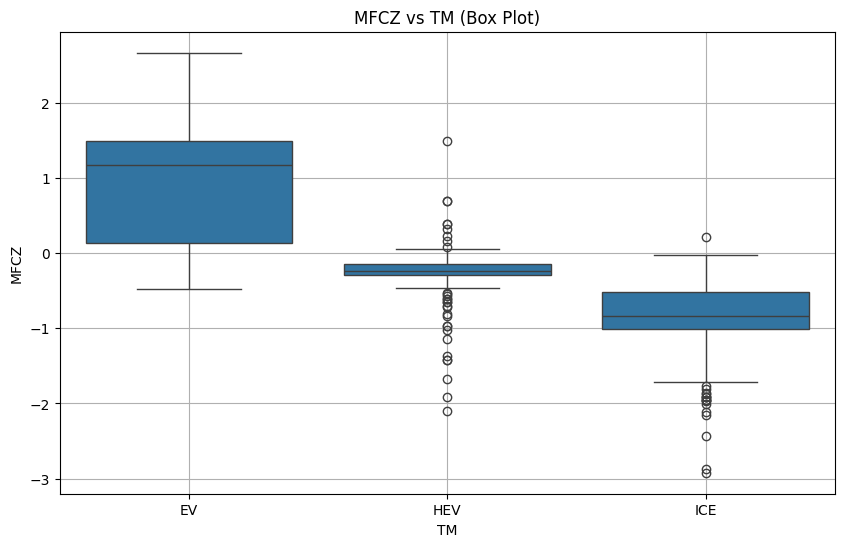

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'MFCZ' is a numeric type. 'TM' should be treated as categorical.
df['MFCZ'] = pd.to_numeric(df['MFCZ'], errors='coerce')

plt.figure(figsize=(10, 6))
# Changed to boxplot as requested
sns.boxplot(x='TM', y='MFCZ', data=df)
plt.title('MFCZ vs TM (Box Plot)')
plt.xlabel('TM')
plt.ylabel('MFCZ')
plt.grid(True)
plt.show()

NaNs in FIn after conversion: 0
NaNs in MFCZ after conversion: 0
NaNs in TM after conversion: 0
Shape of df_plot after dropna: (2835, 16)
dtype of TM in df_plot before hue assignment: category
Unique TM values in df_plot before hue assignment: ['EV', 'HEV', 'ICE']
Categories (3, object): ['EV', 'HEV', 'ICE']


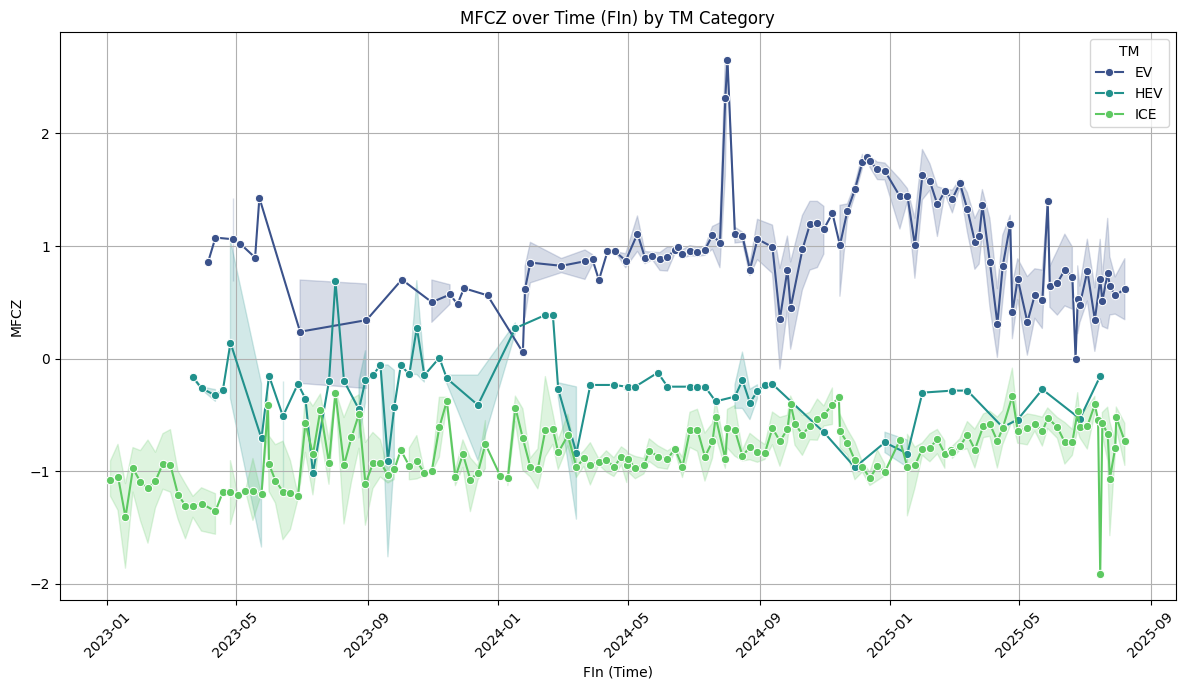

In [6]:
# Ensure 'FIn' is a datetime object and 'MFCZ' is numeric
df['FIn'] = pd.to_datetime(df['FIn'], errors='coerce')
df['MFCZ'] = pd.to_numeric(df['MFCZ'], errors='coerce')

print(f"NaNs in FIn after conversion: {df['FIn'].isnull().sum()}")
print(f"NaNs in MFCZ after conversion: {df['MFCZ'].isnull().sum()}")
print(f"NaNs in TM after conversion: {df['TM'].isnull().sum()}")

# Drop rows where 'FIn', 'TM', or 'MFCZ' could not be converted or are missing
df_plot = df.dropna(subset=['FIn', 'TM', 'MFCZ'])

print(f"Shape of df_plot after dropna: {df_plot.shape}")
print(f"dtype of TM in df_plot before hue assignment: {df_plot['TM'].dtype}")
print(f"Unique TM values in df_plot before hue assignment: {df_plot['TM'].unique()}")

# Explicitly convert 'TM' to string type for hue parameter to prevent potential seaborn issues
df_plot['TM_for_hue'] = df_plot['TM'].astype(str)

plt.figure(figsize=(12, 7))
sns.lineplot(x='FIn', y='MFCZ', hue='TM_for_hue', data=df_plot, marker='o', palette='viridis')
plt.title('MFCZ over Time (FIn) by TM Category')
plt.xlabel('FIn (Time)')
plt.ylabel('MFCZ')
plt.grid(True)
plt.legend(title='TM')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
print(df['TM'].value_counts())

TM
ICE    1454
EV     1242
HEV     139
Name: count, dtype: int64


In [8]:
df['FIn_year'] = df['FIn'].dt.year

# Group by year and TM, then count records
# Added observed=False to address FutureWarning with categorical columns
tm_counts_by_year = df.groupby(['FIn_year', 'TM'], observed=False).size().unstack(fill_value=0)

display(tm_counts_by_year)

TM,EV,HEV,ICE
FIn_year,,,
2023,21,76,393
2024,479,53,617
2025,742,10,444


In [10]:
# Filter out rows where 'TM' is 'HEV'
df_filtered = df[df['TM'] != 'HEV'].copy()

print("Shape of DataFrame before filtering:", df.shape)
print("Shape of DataFrame after filtering (excluding HEV):", df_filtered.shape)

# Display value counts to confirm removal
print("\nValue counts for 'TM' after filtering:")
print(df_filtered['TM'].value_counts())


Shape of DataFrame before filtering: (2835, 17)
Shape of DataFrame after filtering (excluding HEV): (2696, 17)

Value counts for 'TM' after filtering:
TM
ICE    1454
EV     1242
HEV       0
Name: count, dtype: int64


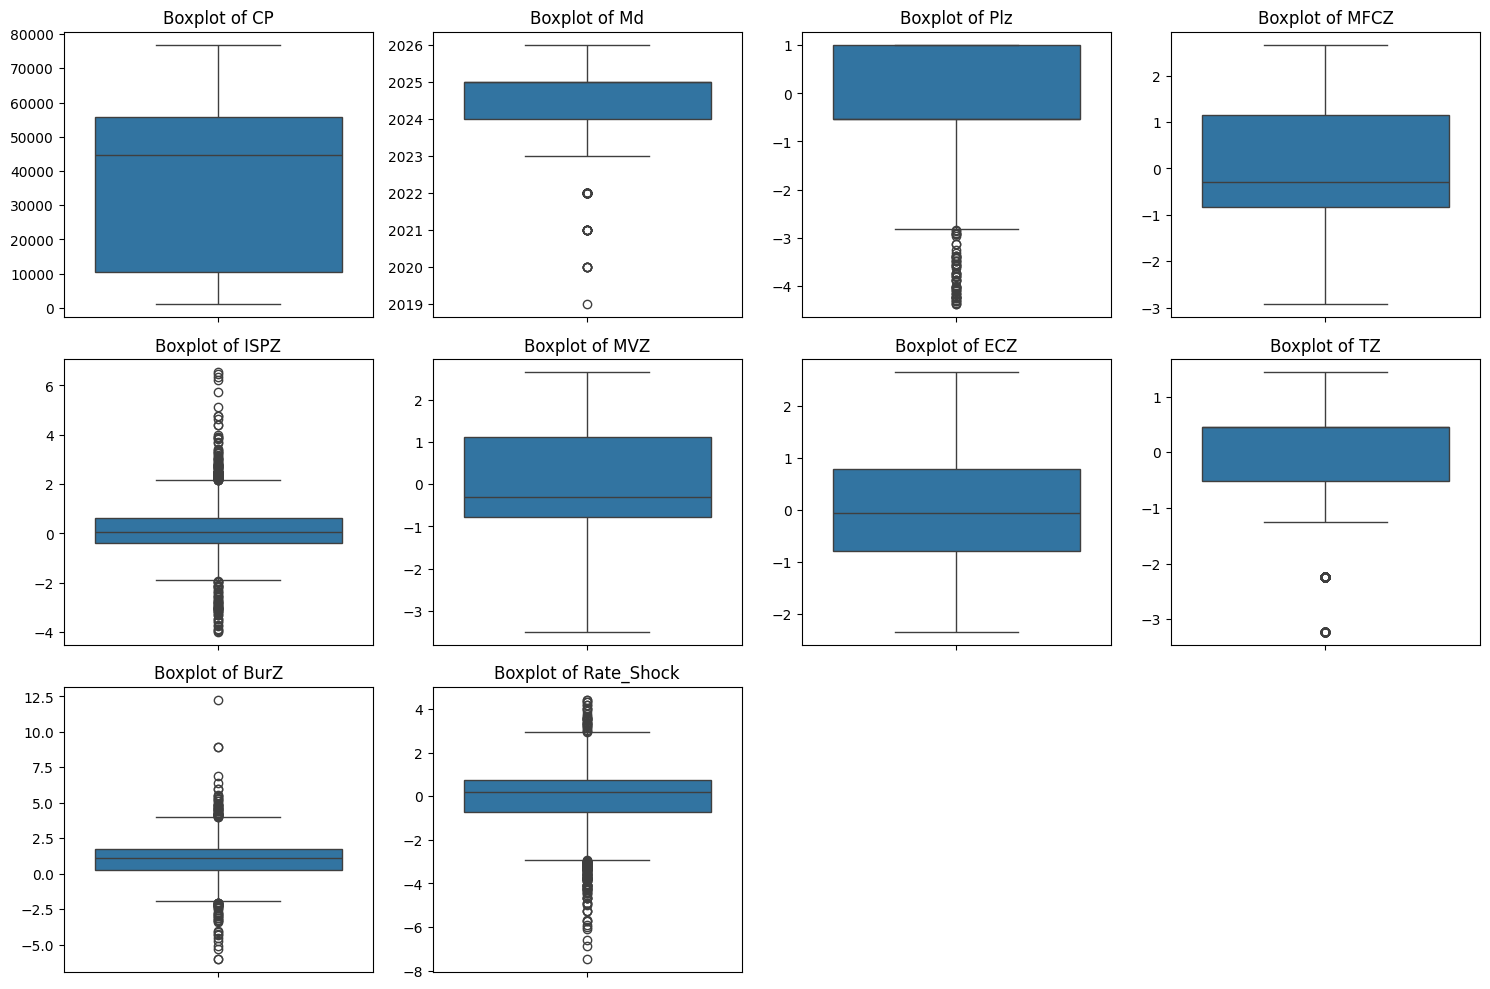

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for box plotting
# Exclude 'FIn_year' as it's a derived year, and 'FIn' and 'Fter' are datetime objects
numerical_cols = df_filtered.select_dtypes(include=['number']).columns.tolist()
if 'FIn_year' in numerical_cols:
    numerical_cols.remove('FIn_year')

# It's good practice to ensure 'MFCZ' is numeric if it's in the list
# (though it should be from previous cells, a check doesn't hurt)
df_filtered['MFCZ'] = pd.to_numeric(df_filtered['MFCZ'], errors='coerce')

# Create boxplots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=df_filtered[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()


In [12]:
# Generate statistical summary of the filtered DataFrame
display(df_filtered.describe(include='all'))


,RAZON,FIn,Fter,ZC,TM,Pt,CP,Md,Plz,MFCZ,ISPZ,MVZ,ECZ,TZ,BurZ,Rate_Shock,FIn_year
count,2696,2696,2696,2696,2696,2696,2696.000000,2696.000000,2696.000000,2696.000000,2696.000000,2696.000000,2696.000000,2696.000000,2696.000000,2696.000000,2696.000000
unique,2,NaN,378,6,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,EXITOSO,NaN,2028-06-23,CDMX Y AREA METROPOLITANA,ICE,UBER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1927,NaN,54,1867,1454,2326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2024-10-03 10:51:05.875370752,NaN,NaN,NaN,NaN,35039.083457,2024.534125,0.050121,0.019325,0.161802,0.025104,-0.011977,0.059088,1.040820,-0.102714,2024.286350
min,NaN,2023-01-04 00:00:00,NaN,NaN,NaN,NaN,1110.000000,2019.000000,-4.381079,-2.921241,-3.978382,-3.489539,-2.340186,-3.221642,-6.018108,-7.479093,2023.000000
25%,NaN,2024-05-16 00:00:00,NaN,NaN,NaN,NaN,10337.500000,2024.000000,-0.527833,-0.838197,-0.376558,-0.786272,-0.779272,-0.524219,0.276374,-0.723660,2024.000000
50%,NaN,2024-11-22 00:00:00,NaN,NaN,NaN,NaN,44770.000000,2025.000000,-0.527833,-0.301836,0.046028,-0.305216,-0.050845,0.456661,1.140585,0.178311,2024.000000
75%,NaN,2025-04-30 00:00:00,NaN,NaN,NaN,NaN,55743.750000,2025.000000,1.013465,1.159128,0.638346,1.124477,0.781643,0.456661,1.769547,0.750700,2025.000000
max,NaN,2025-08-08 00:00:00,NaN,NaN,NaN,NaN,76925.000000,2026.000000,1.013465,2.667896,6.537484,2.651384,2.654740,1.437542,12.263261,4.435043,2025.000000


In [13]:
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers)

columns_to_check = ['ISPZ', 'BurZ', 'Rate_Shock']
outlier_counts = {}

total_records = len(df_filtered)

print("**Overall Outlier Counts and Percentages (excluding HEV):**")
for col in columns_to_check:
    outlier_count = count_outliers_iqr(df_filtered[col])
    outlier_percentage = (outlier_count / total_records) * 100 if total_records > 0 else 0
    outlier_counts[col] = (outlier_count, outlier_percentage)
    print(f"Number of outliers in {col}: {outlier_count} ({outlier_percentage:.2f}%) ")

**Overall Outlier Counts and Percentages (excluding HEV):**
Number of outliers in ISPZ: 147 (5.45%) 
Number of outliers in BurZ: 86 (3.19%) 
Number of outliers in Rate_Shock: 160 (5.93%) 


In [14]:
# Ensure 'FIn_year' exists in df_filtered for grouping
# If df_filtered was created from df that already had 'FIn_year', it's already there.
# Otherwise, create it.
if 'FIn_year' not in df_filtered.columns:
    df_filtered['FIn_year'] = df_filtered['FIn'].dt.year

outliers_by_year = {}

print("**Outlier Counts and Percentages by Year (excluding HEV):**")
for year, group in df_filtered.groupby('FIn_year'):
    year_outliers = {}
    total_records_year = len(group)
    for col in columns_to_check:
        outlier_count = count_outliers_iqr(group[col])
        outlier_percentage = (outlier_count / total_records_year) * 100 if total_records_year > 0 else 0
        year_outliers[col] = (outlier_count, outlier_percentage)
    outliers_by_year[year] = year_outliers

for year, counts in outliers_by_year.items():
    print(f"\nYear {year}:")
    for col, (count, percentage) in counts.items():
        print(f"  Number of outliers in {col}: {count} ({percentage:.2f}%) ")

**Outlier Counts and Percentages by Year (excluding HEV):**

Year 2023:
  Number of outliers in ISPZ: 12 (2.90%) 
  Number of outliers in BurZ: 7 (1.69%) 
  Number of outliers in Rate_Shock: 2 (0.48%) 

Year 2024:
  Number of outliers in ISPZ: 56 (5.11%) 
  Number of outliers in BurZ: 42 (3.83%) 
  Number of outliers in Rate_Shock: 30 (2.74%) 

Year 2025:
  Number of outliers in ISPZ: 68 (5.73%) 
  Number of outliers in BurZ: 47 (3.96%) 
  Number of outliers in Rate_Shock: 63 (5.31%) 


In [14]:
#Aqui descargue filtered_data

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# Separate the df_filtered DataFrame into two based on the 'TM' column
df_ice = df_filtered[df_filtered['TM'] == 'ICE'].copy()
df_ev = df_filtered[df_filtered['TM'] == 'EV'].copy()

print("DataFrame for 'ICE' (df_ice) - first 5 rows:")
display(df_ice.head())

print("\nDataFrame for 'EV' (df_ev) - first 5 rows:")
display(df_ev.head())

DataFrame for 'ICE' (df_ice) - first 5 rows:


,RAZON,FIn,Fter,ZC,TM,Pt,CP,Md,Plz,MFCZ,ISPZ,MVZ,ECZ,TZ,BurZ,Rate_Shock,FIn_year
934,NO EXITOSO,2025-05-23,2025-12-15,NUEVO LEON,ICE,UBER,66350,2025,-4.321798,0.220688,-0.180465,0.128466,-0.050845,0.456661,0.129401,0.637126,2025
1190,EXITOSO,2024-10-25,2025-02-06,CDMX Y AREA METROPOLITANA,ICE,UBER,56420,2024,-0.527833,-0.021920,-0.404683,-0.064399,-1.299577,-0.524219,0.446211,-0.119537,2024
1201,EXITOSO,2025-04-25,2028-04-21,CDMX Y AREA METROPOLITANA,ICE,UBER,9790,2025,-0.527833,-0.084005,0.165171,-0.111050,0.885704,-0.524219,-0.006019,-0.689390,2025
1202,EXITOSO,2025-04-25,2028-04-21,CDMX Y AREA METROPOLITANA,ICE,UBER,15100,2025,-0.527833,-0.084005,1.518924,-0.111050,0.989765,-0.524219,-1.359773,-2.043144,2025
1203,EXITOSO,2025-04-25,2028-04-21,CDMX Y AREA METROPOLITANA,ICE,UBER,6300,2025,-0.527833,-0.084005,0.227662,-0.111050,-1.299577,-0.524219,-0.068510,-0.751882,2025



DataFrame for 'EV' (df_ev) - first 5 rows:


,RAZON,FIn,Fter,ZC,TM,Pt,CP,Md,Plz,MFCZ,ISPZ,MVZ,ECZ,TZ,BurZ,Rate_Shock,FIn_year
0,NO EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,55060,2025,1.013465,2.667896,0.041599,2.651384,1.301948,0.456661,2.590850,0.415062,2024
1,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,7100,2025,1.013465,2.667896,0.041599,2.651384,2.134435,0.456661,2.590850,0.415062,2024
2,NO EXITOSO,2024-08-02,2028-07-28,CDMX Y AREA METROPOLITANA,EV,UBER,9208,2025,1.013465,2.667896,0.380964,2.651384,0.053216,0.456661,2.251485,0.075697,2024
3,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,52916,2025,1.013465,2.667896,0.263851,2.651384,-0.258967,0.456661,2.368598,0.192810,2024
4,EXITOSO,2024-07-31,2028-07-26,CDMX Y AREA METROPOLITANA,EV,UBER,55749,2025,1.013465,2.667896,0.166024,2.651384,0.989765,0.456661,2.466425,0.290638,2024


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# --- Data Preparation for df_ev ---

# Define features (X) and target (y)
X_ev = df_ev.drop(columns=['RAZON', 'TM', 'FIn', 'Fter']) # Drop TM as it's constant, FIn/Fter as datetime
# CORRECTED: Map 'NO EXITOSO' to 1 (positive class) and 'EXITOSO' to 0
y_ev = df_ev['RAZON'].map({'NO EXITOSO': 1, 'EXITOSO': 0})

# Identify categorical and numerical columns for preprocessing
numeric_features_ev = X_ev.select_dtypes(include=['number']).columns.tolist()
categorical_features_ev = X_ev.select_dtypes(include=['object', 'category']).columns.tolist()

# Create a preprocessor using ColumnTransformer
preprocessor_ev = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_ev),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_ev)
    ])

# Split data into training and testing sets
X_train_ev, X_test_ev, y_train_ev, y_test_ev = train_test_split(X_ev, y_ev, test_size=0.2, random_state=42, stratify=y_ev)

print(f"Shape of X_train_ev: {X_train_ev.shape}")
print(f"Shape of X_test_ev: {X_test_ev.shape}")
print(f"Value counts of y_train_ev:\n{y_train_ev.value_counts()}")
print(f"Value counts of y_test_ev:\n{y_test_ev.value_counts()}")

Shape of X_train_ev: (993, 13)
Shape of X_test_ev: (249, 13)
Value counts of y_train_ev:
RAZON
0    663
1    330
Name: count, dtype: int64
Value counts of y_test_ev:
RAZON
0    166
1     83
Name: count, dtype: int64


In [17]:
# Create the Lasso model pipeline
# Logistic Regression with L1 penalty is used for Lasso-like regularization in classification
lasso_model_ev = Pipeline(steps=[
    ('preprocessor', preprocessor_ev),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', random_state=42, C=0.1)) # C is the inverse of regularization strength
])

# Train the model
lasso_model_ev.fit(X_train_ev, y_train_ev)

# Predict probabilities on the test set
y_pred_proba_lasso_ev = lasso_model_ev.predict_proba(X_test_ev)[:, 1] # Get probabilities for the positive class (1: 'NO EXITOSO')

# Predict class labels for evaluation metrics
y_pred_lasso_ev = lasso_model_ev.predict(X_test_ev)

# Evaluate the model
print("--- Lasso Model Evaluation (EV Data) - 'NO EXITOSO' as Positive Class ---")
print(f"ROC AUC Score: {roc_auc_score(y_test_ev, y_pred_proba_lasso_ev):.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ev, y_pred_lasso_ev):.4f}")
print("\nClassification Report:\n", classification_report(y_test_ev, y_pred_lasso_ev))

# Display first few probability predictions
print("\nFirst 10 probability predictions (Probability of 'NO EXITOSO'):")
for i in range(10):
    print(f"Actual (0=EXITOSO, 1=NO EXITOSO): {y_test_ev.iloc[i]}, Predicted Probability: {y_pred_proba_lasso_ev[i]:.4f}")

--- Lasso Model Evaluation (EV Data) - 'NO EXITOSO' as Positive Class ---
ROC AUC Score: 0.7540
Accuracy Score: 0.7108

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.95      0.81       166
           1       0.70      0.23      0.35        83

    accuracy                           0.71       249
   macro avg       0.71      0.59      0.58       249
weighted avg       0.71      0.71      0.66       249


First 10 probability predictions (Probability of 'NO EXITOSO'):
Actual (0=EXITOSO, 1=NO EXITOSO): 1, Predicted Probability: 0.9612
Actual (0=EXITOSO, 1=NO EXITOSO): 1, Predicted Probability: 0.3626
Actual (0=EXITOSO, 1=NO EXITOSO): 0, Predicted Probability: 0.3763
Actual (0=EXITOSO, 1=NO EXITOSO): 1, Predicted Probability: 0.3563
Actual (0=EXITOSO, 1=NO EXITOSO): 0, Predicted Probability: 0.1540
Actual (0=EXITOSO, 1=NO EXITOSO): 0, Predicted Probability: 0.3168
Actual (0=EXITOSO, 1=NO EXITOSO): 0, Predicted Probability: 0.

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline # Make sure Pipeline is imported

# Define the parameter grid for Lasso (Logistic Regression with L1 penalty)
param_grid_lasso = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 4}]
} # C is the inverse of regularization strength, class_weight for imbalance handling

# Create the Lasso pipeline (re-using the preprocessor_ev from before)
lasso_pipeline_for_tuning_ev = Pipeline(steps=[
    ('preprocessor', preprocessor_ev),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)) # Increased max_iter for convergence
])

# Set up GridSearchCV to optimize for 'recall' for the positive class (1: 'NO EXITOSO')
grid_search_lasso_ev = GridSearchCV(
    lasso_pipeline_for_tuning_ev,
    param_grid=param_grid_lasso,
    cv=5, # 5-fold cross-validation
    scoring='recall', # Optimize for recall
    n_jobs=-1, # Use all available cores
    verbose=2
)

print("Starting GridSearchCV for Lasso on EV data with refined class weights...")
grid_search_lasso_ev.fit(X_train_ev, y_train_ev)
print("GridSearchCV for Lasso on EV data completed.")

# Get the best model
best_lasso_model_ev = grid_search_lasso_ev.best_estimator_

print(f"\nBest parameters found: {grid_search_lasso_ev.best_params_}")
print(f"Best cross-validation recall score: {grid_search_lasso_ev.best_score_:.4f}")

# Evaluate the best model on the test set
y_pred_proba_best_lasso_ev = best_lasso_model_ev.predict_proba(X_test_ev)[:, 1]
y_pred_best_lasso_ev = best_lasso_model_ev.predict(X_test_ev)

print("\n--- Tuned Lasso Model Evaluation (EV Data) - 'NO EXITOSO' as Positive Class ---")
print(f"ROC AUC Score: {roc_auc_score(y_test_ev, y_pred_proba_best_lasso_ev):.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ev, y_pred_best_lasso_ev):.4f}")
print("\nClassification Report:\n", classification_report(y_test_ev, y_pred_best_lasso_ev))

# Display first few probability predictions
print("\nFirst 10 probability predictions (Probability of 'NO EXITOSO') from Tuned Model:")
for i in range(10):
    print(f"Actual (0=EXITOSO, 1=NO EXITOSO): {y_test_ev.iloc[i]}, Predicted Probability: {y_pred_proba_best_lasso_ev[i]:.4f}")

Starting GridSearchCV for Lasso on EV data with refined class weights...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
GridSearchCV for Lasso on EV data completed.

Best parameters found: {'classifier__C': 0.01, 'classifier__class_weight': {0: 1, 1: 4}}
Best cross-validation recall score: 0.9970

--- Tuned Lasso Model Evaluation (EV Data) - 'NO EXITOSO' as Positive Class ---
ROC AUC Score: 0.6417
Accuracy Score: 0.3373

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.01      0.01       166
           1       0.33      1.00      0.50        83

    accuracy                           0.34       249
   macro avg       0.67      0.50      0.26       249
weighted avg       0.78      0.34      0.18       249


First 10 probability predictions (Probability of 'NO EXITOSO') from Tuned Model:
Actual (0=EXITOSO, 1=NO EXITOSO): 1, Predicted Probability: 0.8422
Actual (0=EXITOSO, 1=NO EXITOSO): 1, Predicted Probability: 

In [19]:
# Evaluate the best Lasso model on the TRAINING set
y_pred_proba_best_lasso_ev_train = best_lasso_model_ev.predict_proba(X_train_ev)[:, 1]
y_pred_best_lasso_ev_train = best_lasso_model_ev.predict(X_train_ev)

print("--- Tuned Lasso Model Evaluation (EV Data) - TRAINING SET ---")
print(f"ROC AUC Score: {roc_auc_score(y_train_ev, y_pred_proba_best_lasso_ev_train):.4f}")
print(f"Accuracy Score: {accuracy_score(y_train_ev, y_pred_best_lasso_ev_train):.4f}")
print("\nClassification Report (Training Set):\n", classification_report(y_train_ev, y_pred_best_lasso_ev_train))

print("\n" + "="*70 + "\n")

# Evaluate the best Lasso model on the TEST set (re-display for direct comparison)
y_pred_proba_best_lasso_ev_test = best_lasso_model_ev.predict_proba(X_test_ev)[:, 1]
y_pred_best_lasso_ev_test = best_lasso_model_ev.predict(X_test_ev)

print("--- Tuned Lasso Model Evaluation (EV Data) - TEST SET ---")
print(f"ROC AUC Score: {roc_auc_score(y_test_ev, y_pred_proba_best_lasso_ev_test):.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ev, y_pred_best_lasso_ev_test):.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ev, y_pred_best_lasso_ev_test))

--- Tuned Lasso Model Evaluation (EV Data) - TRAINING SET ---
ROC AUC Score: 0.6750
Accuracy Score: 0.3343

Classification Report (Training Set):
               precision    recall  f1-score   support

           0       0.62      0.01      0.01       663
           1       0.33      0.99      0.50       330

    accuracy                           0.33       993
   macro avg       0.48      0.50      0.26       993
weighted avg       0.53      0.33      0.18       993



--- Tuned Lasso Model Evaluation (EV Data) - TEST SET ---
ROC AUC Score: 0.6417
Accuracy Score: 0.3373

Classification Report (Test Set):
               precision    recall  f1-score   support

           0       1.00      0.01      0.01       166
           1       0.33      1.00      0.50        83

    accuracy                           0.34       249
   macro avg       0.67      0.50      0.26       249
weighted avg       0.78      0.34      0.18       249



### Threshold Optimization: Precision-Recall Trade-off

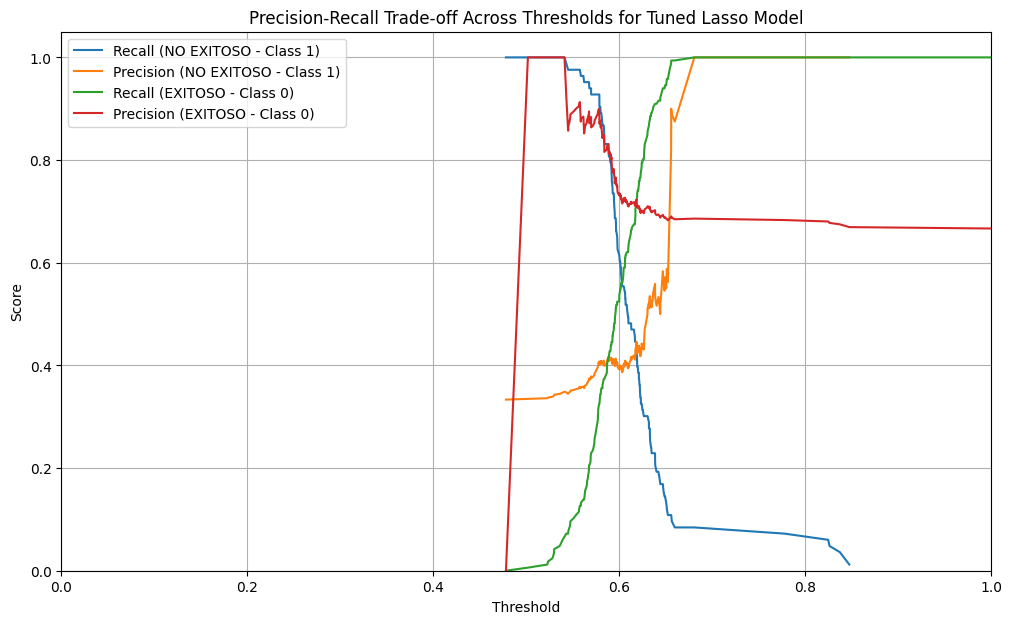

In [20]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities for the positive class (1: 'NO EXITOSO') from the best Lasso model
y_pred_proba = best_lasso_model_ev.predict_proba(X_test_ev)[:, 1]

# Calculate precision, recall, and thresholds for the positive class (NO EXITOSO)
precisions, recalls, thresholds = precision_recall_curve(y_test_ev, y_pred_proba, pos_label=1)

# To analyze the trade-off, we can also calculate metrics for the negative class (EXITOSO)
# This requires re-calculating predictions for each threshold.

thresholds_extended = np.append(thresholds, 1.0) # Add 1.0 to thresholds to include all predictions

precision_0 = []
recall_0 = []

for t in thresholds_extended:
    y_pred_at_t = (y_pred_proba >= t).astype(int)
    # For Class 0 (EXITOSO), we swap the labels for the classification_report
    # to get precision/recall for the original 0 class.
    # More simply: actual 0s, predicted 0s
    true_negatives = np.sum((y_test_ev == 0) & (y_pred_at_t == 0))
    false_positives = np.sum((y_test_ev == 0) & (y_pred_at_t == 1))
    false_negatives = np.sum((y_test_ev == 1) & (y_pred_at_t == 0))
    true_positives = np.sum((y_test_ev == 1) & (y_pred_at_t == 1))

    # Precision for Class 0 (EXITOSO): TP (actual 0, pred 0) / (TP + FP (actual 1, pred 0))
    # For class 0, the 'positive' is 0, so TP_0 = true_negatives, FP_0 = false_negatives
    precision_class_0 = true_negatives / (true_negatives + false_negatives) if (true_negatives + false_negatives) > 0 else 0
    # Recall for Class 0 (EXITOSO): TP (actual 0, pred 0) / (TP + FN (actual 0, pred 1))
    # For class 0, FN_0 = false_positives
    recall_class_0 = true_negatives / (true_negatives + false_positives) if (true_negatives + false_positives) > 0 else 0

    precision_0.append(precision_class_0)
    recall_0.append(recall_class_0)

# Plotting
plt.figure(figsize=(12, 7))
plt.plot(thresholds, recalls[:-1], label='Recall (NO EXITOSO - Class 1)')
plt.plot(thresholds, precisions[:-1], label='Precision (NO EXITOSO - Class 1)')
plt.plot(thresholds_extended, np.array(recall_0), label='Recall (EXITOSO - Class 0)')
plt.plot(thresholds_extended, np.array(precision_0), label='Precision (EXITOSO - Class 0)')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off Across Thresholds for Tuned Lasso Model')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

In [21]:
threshold = 0.59

# Get probabilities for the positive class (1: 'NO EXITOSO') from the best Lasso model
y_pred_proba_ev = best_lasso_model_ev.predict_proba(X_test_ev)[:, 1]

# Apply the specified threshold to get binary predictions
y_pred_at_threshold_ev = (y_pred_proba_ev >= threshold).astype(int)

print(f"--- Tuned Lasso Model Evaluation (EV Data) with Threshold = {threshold} ---")
print(f"ROC AUC Score: {roc_auc_score(y_test_ev, y_pred_proba_ev):.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ev, y_pred_at_threshold_ev):.4f}")
print("\nClassification Report:\n", classification_report(y_test_ev, y_pred_at_threshold_ev))

--- Tuned Lasso Model Evaluation (EV Data) with Threshold = 0.59 ---
ROC AUC Score: 0.6417
Accuracy Score: 0.5502

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.43      0.56       166
           1       0.41      0.80      0.54        83

    accuracy                           0.55       249
   macro avg       0.61      0.61      0.55       249
weighted avg       0.67      0.55      0.55       249



In [22]:
threshold = 0.5785

# --- Evaluation for Training Set with new threshold ---
print(f"--- Tuned Lasso Model Evaluation (EV Data) - TRAINING SET with Threshold = {threshold} ---")
# Get probabilities for the positive class (1: 'NO EXITOSO') from the best Lasso model
y_pred_proba_ev_train = best_lasso_model_ev.predict_proba(X_train_ev)[:, 1]

# Apply the specified threshold to get binary predictions
y_pred_at_threshold_ev_train = (y_pred_proba_ev_train >= threshold).astype(int)

print(f"ROC AUC Score: {roc_auc_score(y_train_ev, y_pred_proba_ev_train):.4f}")
print(f"Accuracy Score: {accuracy_score(y_train_ev, y_pred_at_threshold_ev_train):.4f}")
print("\nClassification Report:\n", classification_report(y_train_ev, y_pred_at_threshold_ev_train))

print("\n" + "="*70 + "\n")

# --- Evaluation for Test Set with new threshold ---
print(f"--- Tuned Lasso Model Evaluation (EV Data) - TEST SET with Threshold = {threshold} ---")
# Get probabilities for the positive class (1: 'NO EXITOSO') from the best Lasso model
y_pred_proba_ev_test = best_lasso_model_ev.predict_proba(X_test_ev)[:, 1]

# Apply the specified threshold to get binary predictions
y_pred_at_threshold_ev_test = (y_pred_proba_ev_test >= threshold).astype(int)

print(f"ROC AUC Score: {roc_auc_score(y_test_ev, y_pred_proba_ev_test):.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ev, y_pred_at_threshold_ev_test):.4f}")
print("\nClassification Report:\n", classification_report(y_test_ev, y_pred_at_threshold_ev_test))

--- Tuned Lasso Model Evaluation (EV Data) - TRAINING SET with Threshold = 0.5785 ---
ROC AUC Score: 0.6750
Accuracy Score: 0.4753

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.26      0.40       663
           1       0.38      0.90      0.53       330

    accuracy                           0.48       993
   macro avg       0.61      0.58      0.47       993
weighted avg       0.69      0.48      0.45       993



--- Tuned Lasso Model Evaluation (EV Data) - TEST SET with Threshold = 0.5785 ---
ROC AUC Score: 0.6417
Accuracy Score: 0.5261

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.33      0.48       166
           1       0.41      0.93      0.57        83

    accuracy                           0.53       249
   macro avg       0.65      0.63      0.52       249
weighted avg       0.74      0.53      0.51       249



### Threshold Optimization for Lasso using F1-score (EV Data)

Optimal F1-score threshold for Lasso model: 0.5785


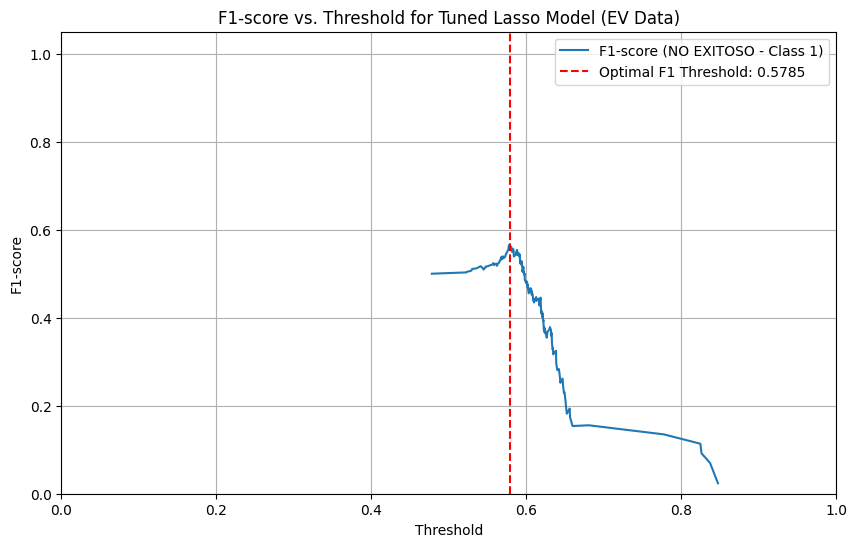

In [23]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

# Reuse precisions, recalls, and thresholds calculated in cell 943a2a0d for the Lasso model on EV data
# y_pred_proba was named y_pred_proba_best_lasso_ev for the best Lasso model
y_pred_proba = best_lasso_model_ev.predict_proba(X_test_ev)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test_ev, y_pred_proba, pos_label=1)

# Calculate F1-scores for each threshold
f1_scores_lasso = 2 * (precisions * recalls) / (precisions + recalls)

# Find the optimal threshold (where F1-score is maximized)
optimal_threshold_idx_lasso = np.argmax(f1_scores_lasso)
optimal_f1_threshold_lasso = thresholds[optimal_threshold_idx_lasso]

print(f"Optimal F1-score threshold for Lasso model: {optimal_f1_threshold_lasso:.4f}")

# Plot F1-score vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores_lasso[:-1], label='F1-score (NO EXITOSO - Class 1)')
plt.axvline(x=optimal_f1_threshold_lasso, color='r', linestyle='--', label=f'Optimal F1 Threshold: {optimal_f1_threshold_lasso:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs. Threshold for Tuned Lasso Model (EV Data)')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

In [24]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Evaluate the best Lasso model on the test set with the optimal F1-score threshold
y_pred_at_optimal_f1_threshold_lasso = (y_pred_proba >= optimal_f1_threshold_lasso).astype(int)

print(f"--- Tuned Lasso Model Evaluation (EV Data) - TEST SET with Optimal F1 Threshold = {optimal_f1_threshold_lasso:.4f} ---")
print(f"ROC AUC Score: {roc_auc_score(y_test_ev, y_pred_proba):.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ev, y_pred_at_optimal_f1_threshold_lasso):.4f}")
print("\nClassification Report:\n", classification_report(y_test_ev, y_pred_at_optimal_f1_threshold_lasso))

--- Tuned Lasso Model Evaluation (EV Data) - TEST SET with Optimal F1 Threshold = 0.5785 ---
ROC AUC Score: 0.6417
Accuracy Score: 0.5261

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.33      0.48       166
           1       0.41      0.93      0.57        83

    accuracy                           0.53       249
   macro avg       0.65      0.63      0.52       249
weighted avg       0.74      0.53      0.51       249



In [25]:
# Evaluate the best Lasso model on the TRAINING set with the optimal F1-score threshold
y_train_pred_proba_lasso = best_lasso_model_ev.predict_proba(X_train_ev)[:, 1]
y_train_pred_at_optimal_f1_threshold_lasso = (y_train_pred_proba_lasso >= optimal_f1_threshold_lasso).astype(int)

print(f"--- Tuned Lasso Model Evaluation (EV Data) - TRAINING SET with Optimal F1 Threshold = {optimal_f1_threshold_lasso:.4f} ---")
print(f"ROC AUC Score: {roc_auc_score(y_train_ev, y_train_pred_proba_lasso):.4f}")
print(f"Accuracy Score: {accuracy_score(y_train_ev, y_train_pred_at_optimal_f1_threshold_lasso):.4f}")
print("\nClassification Report:\n", classification_report(y_train_ev, y_train_pred_at_optimal_f1_threshold_lasso))

--- Tuned Lasso Model Evaluation (EV Data) - TRAINING SET with Optimal F1 Threshold = 0.5785 ---
ROC AUC Score: 0.6750
Accuracy Score: 0.4753

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.26      0.40       663
           1       0.38      0.90      0.53       330

    accuracy                           0.48       993
   macro avg       0.61      0.58      0.47       993
weighted avg       0.69      0.48      0.45       993



### Random Forest Model Training for `df_ev`

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Create the Random Forest model pipeline
# We'll use the same preprocessor as for the Lasso model on df_ev
rf_model_ev = Pipeline(steps=[
    ('preprocessor', preprocessor_ev),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("Training Random Forest model for EV data...")
# Train the model
rf_model_ev.fit(X_train_ev, y_train_ev)
print("Random Forest model training completed.")

# --- Evaluate on Training Set ---
print("\n--- Random Forest Model Evaluation (EV Data) - TRAINING SET ---")
y_train_pred_proba_rf_ev = rf_model_ev.predict_proba(X_train_ev)[:, 1]
y_train_pred_rf_ev = rf_model_ev.predict(X_train_ev)

print(f"ROC AUC Score (Train): {roc_auc_score(y_train_ev, y_train_pred_proba_rf_ev):.4f}")
print(f"Accuracy Score (Train): {accuracy_score(y_train_ev, y_train_pred_rf_ev):.4f}")
print("\nClassification Report (Training Set):\n", classification_report(y_train_ev, y_train_pred_rf_ev))

print("\n" + "="*70 + "\n")

# --- Evaluate on Test Set ---
print("--- Random Forest Model Evaluation (EV Data) - TEST SET ---")
y_test_pred_proba_rf_ev = rf_model_ev.predict_proba(X_test_ev)[:, 1]
y_test_pred_rf_ev = rf_model_ev.predict(X_test_ev)

print(f"ROC AUC Score (Test): {roc_auc_score(y_test_ev, y_test_pred_proba_rf_ev):.4f}")
print(f"Accuracy Score (Test): {accuracy_score(y_test_ev, y_test_pred_rf_ev):.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ev, y_test_pred_rf_ev))

Training Random Forest model for EV data...
Random Forest model training completed.

--- Random Forest Model Evaluation (EV Data) - TRAINING SET ---
ROC AUC Score (Train): 1.0000
Accuracy Score (Train): 1.0000

Classification Report (Training Set):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       663
           1       1.00      1.00      1.00       330

    accuracy                           1.00       993
   macro avg       1.00      1.00      1.00       993
weighted avg       1.00      1.00      1.00       993



--- Random Forest Model Evaluation (EV Data) - TEST SET ---
ROC AUC Score (Test): 0.7227
Accuracy Score (Test): 0.7149

Classification Report (Test Set):
               precision    recall  f1-score   support

           0       0.74      0.89      0.81       166
           1       0.62      0.36      0.46        83

    accuracy                           0.71       249
   macro avg       0.68      0.63      0.63     

### Hyperparameter Tuning for Random Forest Model (`df_ev`) using GridSearchCV

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Define the parameter grid for RandomForestClassifier
param_grid_rf_ev = {
    'classifier__n_estimators': [100, 200, 300], # Number of trees in the forest
    'classifier__max_depth': [None, 10, 20],   # Maximum depth of the tree
    'classifier__min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'classifier__class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}]
}

# Create the Random Forest pipeline for tuning (re-using preprocessor_ev)
rf_pipeline_for_tuning_ev = Pipeline(steps=[
    ('preprocessor', preprocessor_ev),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Set up GridSearchCV to optimize for 'recall' of the positive class (1: 'NO EXITOSO')
grid_search_rf_ev = GridSearchCV(
    rf_pipeline_for_tuning_ev,
    param_grid=param_grid_rf_ev,
    cv=5, # 5-fold cross-validation
    scoring='recall', # Optimize for recall
    n_jobs=-1, # Use all available cores
    verbose=2
)

print("Starting GridSearchCV for Random Forest on EV data...")
grid_search_rf_ev.fit(X_train_ev, y_train_ev)
print("GridSearchCV for Random Forest on EV data completed.")

# Get the best model
best_rf_model_ev = grid_search_rf_ev.best_estimator_

print(f"\nBest parameters found: {grid_search_rf_ev.best_params_}")
print(f"Best cross-validation recall score: {grid_search_rf_ev.best_score_:.4f}")

# --- Evaluate the best model on the TRAINING set ---
print("\n--- Tuned Random Forest Model Evaluation (EV Data) - TRAINING SET ---")
y_train_pred_proba_best_rf_ev = best_rf_model_ev.predict_proba(X_train_ev)[:, 1]
y_train_pred_best_rf_ev = best_rf_model_ev.predict(X_train_ev)

print(f"ROC AUC Score (Train): {roc_auc_score(y_train_ev, y_train_pred_proba_best_rf_ev):.4f}")
print(f"Accuracy Score (Train): {accuracy_score(y_train_ev, y_train_pred_best_rf_ev):.4f}")
print("\nClassification Report (Training Set):\n", classification_report(y_train_ev, y_train_pred_best_rf_ev))

print("\n" + "="*70 + "\n")

# --- Evaluate the best model on the TEST set ---
print("--- Tuned Random Forest Model Evaluation (EV Data) - TEST SET ---")
y_test_pred_proba_best_rf_ev = best_rf_model_ev.predict_proba(X_test_ev)[:, 1]
y_test_pred_best_rf_ev = best_rf_model_ev.predict(X_test_ev)

print(f"ROC AUC Score (Test): {roc_auc_score(y_test_ev, y_test_pred_proba_best_rf_ev):.4f}")
print(f"Accuracy Score (Test): {accuracy_score(y_test_ev, y_test_pred_best_rf_ev):.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ev, y_test_pred_best_rf_ev))

Starting GridSearchCV for Random Forest on EV data...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV for Random Forest on EV data completed.

Best parameters found: {'classifier__class_weight': {0: 1, 1: 3}, 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 300}
Best cross-validation recall score: 0.6000

--- Tuned Random Forest Model Evaluation (EV Data) - TRAINING SET ---
ROC AUC Score (Train): 0.9653
Accuracy Score (Train): 0.8862

Classification Report (Training Set):
               precision    recall  f1-score   support

           0       0.95      0.87      0.91       663
           1       0.78      0.91      0.84       330

    accuracy                           0.89       993
   macro avg       0.87      0.89      0.88       993
weighted avg       0.90      0.89      0.89       993



--- Tuned Random Forest Model Evaluation (EV Data) - TEST SET ---
ROC AUC Score (Test): 0.7065
Accuracy Score (Test): 0.65

### Hyperparameter Tuning v2 for Random Forest Model (`df_ev`) to Reduce Overfitting

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Define the updated parameter grid for RandomForestClassifier
# Focusing on shallower trees and higher min_samples_leaf to combat overfitting
param_grid_rf_ev_v2 = {
    'classifier__n_estimators': [100, 200, 300], # Keep n_estimators range
    'classifier__max_depth': [5, 8, 10],   # Reduced maximum depth values
    'classifier__min_samples_leaf': [4, 8, 15], # Increased minimum samples per leaf
    'classifier__class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}]
}

# Create the Random Forest pipeline for tuning (re-using preprocessor_ev)
rf_pipeline_for_tuning_ev_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor_ev),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Set up GridSearchCV to optimize for 'recall' of the positive class (1: 'NO EXITOSO')
grid_search_rf_ev_v2 = GridSearchCV(
    rf_pipeline_for_tuning_ev_v2,
    param_grid=param_grid_rf_ev_v2,
    cv=5, # 5-fold cross-validation
    scoring='recall', # Optimize for recall
    n_jobs=-1, # Use all available cores
    verbose=2
)

print("Starting GridSearchCV v2 for Random Forest on EV data (focus on reducing overfitting)...")
grid_search_rf_ev_v2.fit(X_train_ev, y_train_ev)
print("GridSearchCV v2 for Random Forest on EV data completed.")

# Get the best model from the second tuning phase
best_rf_model_ev_v2 = grid_search_rf_ev_v2.best_estimator_

print(f"\nBest parameters found (v2): {grid_search_rf_ev_v2.best_params_}")
print(f"Best cross-validation recall score (v2): {grid_search_rf_ev_v2.best_score_:.4f}")

# --- Evaluate the best model (v2) on the TRAINING set ---
print("\n--- Tuned Random Forest Model Evaluation v2 (EV Data) - TRAINING SET ---")
y_train_pred_proba_best_rf_ev_v2 = best_rf_model_ev_v2.predict_proba(X_train_ev)[:, 1]
y_train_pred_best_rf_ev_v2 = best_rf_model_ev_v2.predict(X_train_ev)

print(f"ROC AUC Score (Train): {roc_auc_score(y_train_ev, y_train_pred_proba_best_rf_ev_v2):.4f}")
print(f"Accuracy Score (Train): {accuracy_score(y_train_ev, y_train_pred_best_rf_ev_v2):.4f}")
print("\nClassification Report (Training Set):\n", classification_report(y_train_ev, y_train_pred_best_rf_ev_v2))

print("\n" + "="*70 + "\n")

# --- Evaluate the best model (v2) on the TEST set ---
print("--- Tuned Random Forest Model Evaluation v2 (EV Data) - TEST SET ---")
y_test_pred_proba_best_rf_ev_v2 = best_rf_model_ev_v2.predict_proba(X_test_ev)[:, 1]
y_test_pred_best_rf_ev_v2 = best_rf_model_ev_v2.predict(X_test_ev)

print(f"ROC AUC Score (Test): {roc_auc_score(y_test_ev, y_test_pred_proba_best_rf_ev_v2):.4f}")
print(f"Accuracy Score (Test): {accuracy_score(y_test_ev, y_test_pred_best_rf_ev_v2):.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ev, y_test_pred_best_rf_ev_v2))

Starting GridSearchCV v2 for Random Forest on EV data (focus on reducing overfitting)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV v2 for Random Forest on EV data completed.

Best parameters found (v2): {'classifier__class_weight': {0: 1, 1: 3}, 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 15, 'classifier__n_estimators': 100}
Best cross-validation recall score (v2): 0.7636

--- Tuned Random Forest Model Evaluation v2 (EV Data) - TRAINING SET ---
ROC AUC Score (Train): 0.8298
Accuracy Score (Train): 0.6465

Classification Report (Training Set):
               precision    recall  f1-score   support

           0       0.88      0.54      0.67       663
           1       0.48      0.85      0.62       330

    accuracy                           0.65       993
   macro avg       0.68      0.70      0.64       993
weighted avg       0.75      0.65      0.65       993



--- Tuned Random Forest Model Evaluation v2 (EV Data) - TEST SET ---
RO

### Hyperparameter Tuning v3 for Random Forest Model (`df_ev`) with `min_samples_split` and `ccp_alpha`

### Hyperparameter Tuning v4 for Random Forest Model (`df_ev`) - More Aggressive Overfitting Reduction

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Define the updated parameter grid for RandomForestClassifier (v5) - Less aggressive regularization to combat extreme underfitting
param_grid_rf_ev_v5 = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 8],   # Increased max_depth slightly from v4 to allow more complexity
    'classifier__min_samples_leaf': [10, 15, 20], # Decreased min_samples_leaf slightly from v4
    'classifier__min_samples_split': [2, 5, 10], # Keep previous range
    'classifier__ccp_alpha': [0.0, 0.001, 0.005], # Keep previous range
    'classifier__class_weight': [None, {0: 1, 1: 1.5}, {0: 1, 1: 2}] # Further adjust class_weight to be less aggressive, including None
}

# Create the Random Forest pipeline for tuning (re-using preprocessor_ev)
rf_pipeline_for_tuning_ev_v5 = Pipeline(steps=[
    ('preprocessor', preprocessor_ev),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Set up GridSearchCV to optimize for 'recall' of the positive class (1: 'NO EXITOSO')
grid_search_rf_ev_v5 = GridSearchCV(
    rf_pipeline_for_tuning_ev_v5,
    param_grid=param_grid_rf_ev_v5,
    cv=5, # 5-fold cross-validation
    scoring='recall', # Optimize for recall
    n_jobs=-1, # Use all available cores
    verbose=2
)

print("Starting GridSearchCV v5 for Random Forest on EV data (less aggressive regularization after extreme underfitting)...")
grid_search_rf_ev_v5.fit(X_train_ev, y_train_ev)
print("GridSearchCV v5 for Random Forest on EV data completed.")

# Get the best model from the fifth tuning phase
best_rf_model_ev_v5 = grid_search_rf_ev_v5.best_estimator_

print(f"\nBest parameters found (v5): {grid_search_rf_ev_v5.best_params_}")
print(f"Best cross-validation recall score (v5): {grid_search_rf_ev_v5.best_score_:.4f}")

# --- Evaluate the best model (v5) on the TRAINING set ---
print("\n--- Tuned Random Forest Model Evaluation v5 (EV Data) - TRAINING SET ---")
y_train_pred_proba_best_rf_ev_v5 = best_rf_model_ev_v5.predict_proba(X_train_ev)[:, 1]
y_train_pred_best_rf_ev_v5 = best_rf_model_ev_v5.predict(X_train_ev)

print(f"ROC AUC Score (Train): {roc_auc_score(y_train_ev, y_train_pred_proba_best_rf_ev_v5):.4f}")
print(f"Accuracy Score (Train): {accuracy_score(y_train_ev, y_train_pred_best_rf_ev_v5):.4f}")
print("\nClassification Report (Training Set):\n", classification_report(y_train_ev, y_train_pred_best_rf_ev_v5))

print("\n" + "="*70 + "\n")

# --- Evaluate the best model (v5) on the TEST set ---
print("--- Tuned Random Forest Model Evaluation v5 (EV Data) - TEST SET ---")
y_test_pred_proba_best_rf_ev_v5 = best_rf_model_ev_v5.predict_proba(X_test_ev)[:, 1]
y_test_pred_best_rf_ev_v5 = best_rf_model_ev_v5.predict(X_test_ev)

print(f"ROC AUC Score (Test): {roc_auc_score(y_test_ev, y_test_pred_proba_best_rf_ev_v5):.4f}")
print(f"Accuracy Score (Test): {accuracy_score(y_test_ev, y_test_pred_best_rf_ev_v5):.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ev, y_test_pred_best_rf_ev_v5))

Starting GridSearchCV v5 for Random Forest on EV data (less aggressive regularization after extreme underfitting)...
Fitting 5 folds for each of 486 candidates, totalling 2430 fits
GridSearchCV v5 for Random Forest on EV data completed.

Best parameters found (v5): {'classifier__ccp_alpha': 0.001, 'classifier__class_weight': {0: 1, 1: 2}, 'classifier__max_depth': 8, 'classifier__min_samples_leaf': 15, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best cross-validation recall score (v5): 0.5848

--- Tuned Random Forest Model Evaluation v5 (EV Data) - TRAINING SET ---
ROC AUC Score (Train): 0.8552
Accuracy Score (Train): 0.7956

Classification Report (Training Set):
               precision    recall  f1-score   support

           0       0.86      0.83      0.84       663
           1       0.68      0.72      0.70       330

    accuracy                           0.80       993
   macro avg       0.77      0.78      0.77       993
weighted avg       0.80      0.

### Hyperparameter Tuning v6 for Random Forest Model (`df_ev`) - Further Overfitting Reduction

In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Define the updated parameter grid for RandomForestClassifier (v6) - More aggressive regularization
param_grid_rf_ev_v6 = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [4, 6],   # Further reduced maximum depth values
    'classifier__min_samples_leaf': [20, 30], # Increased minimum samples per leaf
    'classifier__min_samples_split': [10, 20], # Increased minimum samples to split
    'classifier__max_features': ['sqrt', 0.5], # Reduced max_features to introduce more randomness
    'classifier__ccp_alpha': [0.001, 0.005, 0.01], # Increased ccp_alpha
    'classifier__class_weight': ['balanced', {0: 1, 1: 2}]
}

# Create the Random Forest pipeline for tuning (re-using preprocessor_ev)
rf_pipeline_for_tuning_ev_v6 = Pipeline(steps=[
    ('preprocessor', preprocessor_ev),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Set up GridSearchCV to optimize for 'recall' of the positive class (1: 'NO EXITOSO')
grid_search_rf_ev_v6 = GridSearchCV(
    rf_pipeline_for_tuning_ev_v6,
    param_grid=param_grid_rf_ev_v6,
    cv=5, # 5-fold cross-validation
    scoring='recall', # Optimize for recall
    n_jobs=-1, # Use all available cores
    verbose=2
)

print("Starting GridSearchCV v6 for Random Forest on EV data (further overfitting reduction)...")
grid_search_rf_ev_v6.fit(X_train_ev, y_train_ev)
print("GridSearchCV v6 for Random Forest on EV data completed.")

# Get the best model from the sixth tuning phase
best_rf_model_ev_v6 = grid_search_rf_ev_v6.best_estimator_

print(f"\nBest parameters found (v6): {grid_search_rf_ev_v6.best_params_}")
print(f"Best cross-validation recall score (v6): {grid_search_rf_ev_v6.best_score_:.4f}")

# --- Evaluate the best model (v6) on the TRAINING set ---
print("\n--- Tuned Random Forest Model Evaluation v6 (EV Data) - TRAINING SET ---")
y_train_pred_proba_best_rf_ev_v6 = best_rf_model_ev_v6.predict_proba(X_train_ev)[:, 1]
y_train_pred_best_rf_ev_v6 = best_rf_model_ev_v6.predict(X_train_ev)

print(f"ROC AUC Score (Train): {roc_auc_score(y_train_ev, y_train_pred_proba_best_rf_ev_v6):.4f}")
print(f"Accuracy Score (Train): {accuracy_score(y_train_ev, y_train_pred_best_rf_ev_v6):.4f}")
print("\nClassification Report (Training Set):\n", classification_report(y_train_ev, y_train_pred_best_rf_ev_v6))

print("\n" + "="*70 + "\n")

# --- Evaluate the best model (v6) on the TEST set ---
print("--- Tuned Random Forest Model Evaluation v6 (EV Data) - TEST SET ---")
y_test_pred_proba_best_rf_ev_v6 = best_rf_model_ev_v6.predict_proba(X_test_ev)[:, 1]
y_test_pred_best_rf_ev_v6 = best_rf_model_ev_v6.predict(X_test_ev)

print(f"ROC AUC Score (Test): {roc_auc_score(y_test_ev, y_test_pred_proba_best_rf_ev_v6):.4f}")
print(f"Accuracy Score (Test): {accuracy_score(y_test_ev, y_test_pred_best_rf_ev_v6):.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ev, y_test_pred_best_rf_ev_v6))

Starting GridSearchCV v6 for Random Forest on EV data (further overfitting reduction)...
Fitting 5 folds for each of 192 candidates, totalling 960 fits
GridSearchCV v6 for Random Forest on EV data completed.

Best parameters found (v6): {'classifier__ccp_alpha': 0.005, 'classifier__class_weight': 'balanced', 'classifier__max_depth': 6, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 20, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
Best cross-validation recall score (v6): 0.6000

--- Tuned Random Forest Model Evaluation v6 (EV Data) - TRAINING SET ---
ROC AUC Score (Train): 0.8002
Accuracy Score (Train): 0.7402

Classification Report (Training Set):
               precision    recall  f1-score   support

           0       0.83      0.77      0.80       663
           1       0.60      0.67      0.63       330

    accuracy                           0.74       993
   macro avg       0.71      0.72      0.72       993
weighted avg       0.75  

### Evaluating Overfitting for Tuned Random Forest Model (EV Data v6)

### LightGBM Model Training for `df_ev`

In [31]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Define the parameter grid for LightGBM
# Starting with a reasonable range, focusing on performance with recall as the metric
param_grid_lgbm_ev = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 8, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__num_leaves': [20, 31, 40], # Number of leaves in one tree
    'classifier__class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}] # Handling class imbalance
}

# Create the LightGBM pipeline for tuning (re-using preprocessor_ev)
# Note: LightGBM can handle categorical features natively if specified, but our preprocessor already handles it with OneHotEncoder.
# For native handling, you would pass `categorical_feature` argument to LGBMClassifier.fit()
lgbm_pipeline_for_tuning_ev = Pipeline(steps=[
    ('preprocessor', preprocessor_ev),
    ('classifier', lgb.LGBMClassifier(random_state=42, n_jobs=-1))
])

# Set up GridSearchCV to optimize for 'recall' of the positive class (1: 'NO EXITOSO')
grid_search_lgbm_ev = GridSearchCV(
    lgbm_pipeline_for_tuning_ev,
    param_grid=param_grid_lgbm_ev,
    cv=5, # 5-fold cross-validation
    scoring='recall', # Optimize for recall
    n_jobs=-1, # Use all available cores
    verbose=2
)

print("Starting GridSearchCV for LightGBM on EV data...")
grid_search_lgbm_ev.fit(X_train_ev, y_train_ev)
print("GridSearchCV for LightGBM on EV data completed.")

# Get the best model
best_lgbm_model_ev = grid_search_lgbm_ev.best_estimator_

print(f"\nBest parameters found: {grid_search_lgbm_ev.best_params_}")
print(f"Best cross-validation recall score: {grid_search_lgbm_ev.best_score_:.4f}")

# --- Evaluate the best model on the TRAINING set ---
print("\n--- Tuned LightGBM Model Evaluation (EV Data) - TRAINING SET ---")
y_train_pred_proba_best_lgbm_ev = best_lgbm_model_ev.predict_proba(X_train_ev)[:, 1]
y_train_pred_best_lgbm_ev = best_lgbm_model_ev.predict(X_train_ev)

print(f"ROC AUC Score (Train): {roc_auc_score(y_train_ev, y_train_pred_proba_best_lgbm_ev):.4f}")
print(f"Accuracy Score (Train): {accuracy_score(y_train_ev, y_train_pred_best_lgbm_ev):.4f}")
print("\nClassification Report (Training Set):\n", classification_report(y_train_ev, y_train_pred_best_lgbm_ev))

print("\n" + "="*70 + "\n")

# --- Evaluate the best model on the TEST set ---
print("--- Tuned LightGBM Model Evaluation (EV Data) - TEST SET ---")
y_test_pred_proba_best_lgbm_ev = best_lgbm_model_ev.predict_proba(X_test_ev)[:, 1]
y_test_pred_best_lgbm_ev = best_lgbm_model_ev.predict(X_test_ev)

print(f"ROC AUC Score (Test): {roc_auc_score(y_test_ev, y_test_pred_proba_best_lgbm_ev):.4f}")
print(f"Accuracy Score (Test): {accuracy_score(y_test_ev, y_test_pred_best_lgbm_ev):.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ev, y_test_pred_best_lgbm_ev))


Starting GridSearchCV for LightGBM on EV data...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Info] Number of positive: 330, number of negative: 663
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000232 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1302
[LightGBM] [Info] Number of data points in the train set: 993, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.598911 -> initscore=0.400930
[LightGBM] [Info] Start training from score 0.400930
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Threshold Optimization for LightGBM: Precision-Recall Trade-off

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


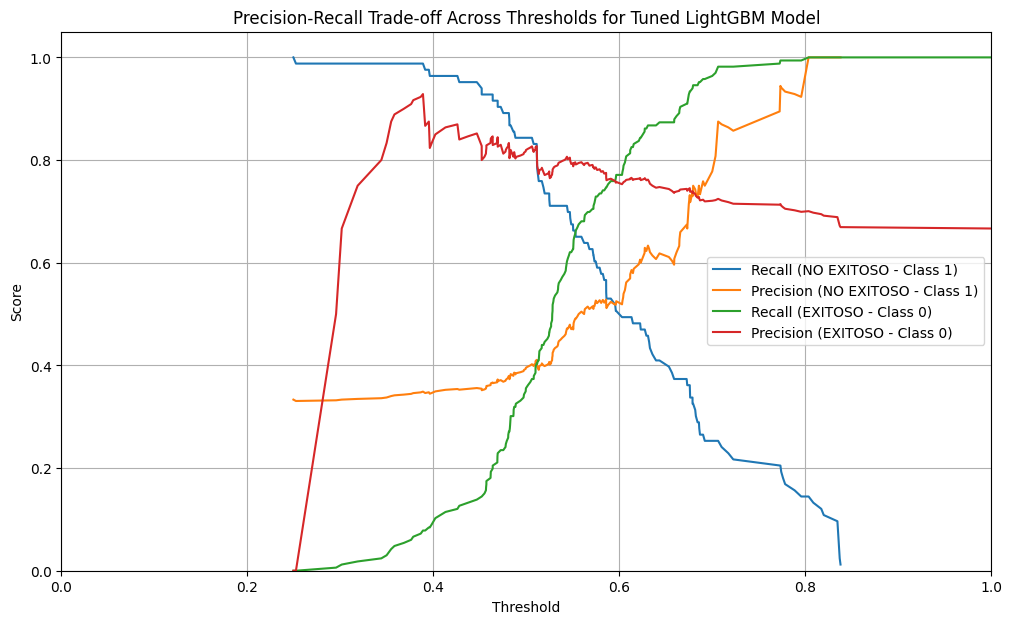

In [77]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities for the positive class (1: 'NO EXITOSO') from the best LightGBM model
y_pred_proba_lgbm = best_lgbm_model_ev.predict_proba(X_test_ev)[:, 1]

# Calculate precision, recall, and thresholds for the positive class (NO EXITOSO)
precisions_lgbm, recalls_lgbm, thresholds_lgbm = precision_recall_curve(y_test_ev, y_pred_proba_lgbm, pos_label=1)

# To analyze the trade-off, we can also calculate metrics for the negative class (EXITOSO)
# This requires re-calculating predictions for each threshold.

thresholds_extended_lgbm = np.append(thresholds_lgbm, 1.0) # Add 1.0 to thresholds to include all predictions

precision_0_lgbm = []
recall_0_lgbm = []

for t in thresholds_extended_lgbm:
    y_pred_at_t_lgbm = (y_pred_proba_lgbm >= t).astype(int)

    # For Class 0 (EXITOSO), we swap the labels for the classification_report
    # to get precision/recall for the original 0 class.
    # More simply: actual 0s, predicted 0s
    true_negatives_lgbm = np.sum((y_test_ev == 0) & (y_pred_at_t_lgbm == 0))
    false_positives_lgbm = np.sum((y_test_ev == 0) & (y_pred_at_t_lgbm == 1))
    false_negatives_lgbm = np.sum((y_test_ev == 1) & (y_pred_at_t_lgbm == 0))
    true_positives_lgbm = np.sum((y_test_ev == 1) & (y_pred_at_t_lgbm == 1))

    # Precision for Class 0 (EXITOSO): TP (actual 0, pred 0) / (TP + FP (actual 1, pred 0))
    # For class 0, the 'positive' is 0, so TP_0 = true_negatives, FP_0 = false_negatives
    precision_class_0_lgbm = true_negatives_lgbm / (true_negatives_lgbm + false_negatives_lgbm) if (true_negatives_lgbm + false_negatives_lgbm) > 0 else 0
    # Recall for Class 0 (EXITOSO): TP (actual 0, pred 0) / (TP + FN (actual 0, pred 1))
    # For class 0, FN_0 = false_positives
    recall_class_0_lgbm = true_negatives_lgbm / (true_negatives_lgbm + false_positives_lgbm) if (true_negatives_lgbm + false_positives_lgbm) > 0 else 0

    precision_0_lgbm.append(precision_class_0_lgbm)
    recall_0_lgbm.append(recall_class_0_lgbm)

# Plotting
plt.figure(figsize=(12, 7))
plt.plot(thresholds_lgbm, recalls_lgbm[:-1], label='Recall (NO EXITOSO - Class 1)')
plt.plot(thresholds_lgbm, precisions_lgbm[:-1], label='Precision (NO EXITOSO - Class 1)')
plt.plot(thresholds_extended_lgbm, np.array(recall_0_lgbm), label='Recall (EXITOSO - Class 0)')
plt.plot(thresholds_extended_lgbm, np.array(precision_0_lgbm), label='Precision (EXITOSO - Class 0)')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off Across Thresholds for Tuned LightGBM Model')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

In [33]:
threshold_lgbm = 0.54

# Get probabilities for the positive class (1: 'NO EXITOSO') from the best LightGBM model
y_pred_proba_ev_lgbm = best_lgbm_model_ev.predict_proba(X_test_ev)[:, 1]

# Apply the specified threshold to get binary predictions
y_pred_at_threshold_ev_lgbm = (y_pred_proba_ev_lgbm >= threshold_lgbm).astype(int)

print(f"--- Tuned LightGBM Model Evaluation (EV Data) with Threshold = {threshold_lgbm} ---")
print(f"ROC AUC Score: {roc_auc_score(y_test_ev, y_pred_proba_ev_lgbm):.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ev, y_pred_at_threshold_ev_lgbm):.4f}")
print("\nClassification Report:\n", classification_report(y_test_ev, y_pred_at_threshold_ev_lgbm))

--- Tuned LightGBM Model Evaluation (EV Data) with Threshold = 0.54 ---
ROC AUC Score: 0.7063
Accuracy Score: 0.6225

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.58      0.67       166
           1       0.46      0.71      0.56        83

    accuracy                           0.62       249
   macro avg       0.63      0.64      0.61       249
weighted avg       0.69      0.62      0.63       249



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [34]:
threshold = 0.5660

# --- Evaluation for Training Set with new threshold ---
print(f"--- Tuned LightGBM Model Evaluation (EV Data) - TRAINING SET with Threshold = {threshold} ---")
# Get probabilities for the positive class (1: 'NO EXITOSO') from the best LightGBM model
y_pred_proba_lgbm_train = best_lgbm_model_ev.predict_proba(X_train_ev)[:, 1]

# Apply the specified threshold to get binary predictions
y_pred_at_threshold_lgbm_train = (y_pred_proba_lgbm_train >= threshold).astype(int)

print(f"ROC AUC Score: {roc_auc_score(y_train_ev, y_pred_proba_lgbm_train):.4f}")
print(f"Accuracy Score: {accuracy_score(y_train_ev, y_pred_at_threshold_lgbm_train):.4f}")
print("\nClassification Report:\n", classification_report(y_train_ev, y_pred_at_threshold_lgbm_train))

print("\n" + "="*70 + "\n")

# --- Evaluation for Test Set with new threshold ---
print(f"--- Tuned LightGBM Model Evaluation (EV Data) - TEST SET with Threshold = {threshold} ---")
# Get probabilities for the positive class (1: 'NO EXITOSO') from the best LightGBM model
y_pred_proba_lgbm_test = best_lgbm_model_ev.predict_proba(X_test_ev)[:, 1]

# Apply the specified threshold to get binary predictions
y_pred_at_threshold_lgbm_test = (y_pred_proba_lgbm_test >= threshold).astype(int)

print(f"ROC AUC Score: {roc_auc_score(y_test_ev, y_pred_proba_lgbm_test):.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ev, y_pred_at_threshold_lgbm_test):.4f}")
print("\nClassification Report:\n", classification_report(y_test_ev, y_pred_at_threshold_lgbm_test))

--- Tuned LightGBM Model Evaluation (EV Data) - TRAINING SET with Threshold = 0.566 ---
ROC AUC Score: 0.8413
Accuracy Score: 0.7553

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.78      0.81       663
           1       0.62      0.70      0.66       330

    accuracy                           0.76       993
   macro avg       0.73      0.74      0.73       993
weighted avg       0.77      0.76      0.76       993



--- Tuned LightGBM Model Evaluation (EV Data) - TEST SET with Threshold = 0.566 ---
ROC AUC Score: 0.7063
Accuracy Score: 0.6787

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.70      0.74       166
           1       0.51      0.64      0.57        83

    accuracy                           0.68       249
   macro avg       0.65      0.67      0.66       249
weighted avg       0.70      0.68      0.69       249



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Threshold Optimization for LightGBM using F1-score

Optimal F1-score threshold: 0.5660


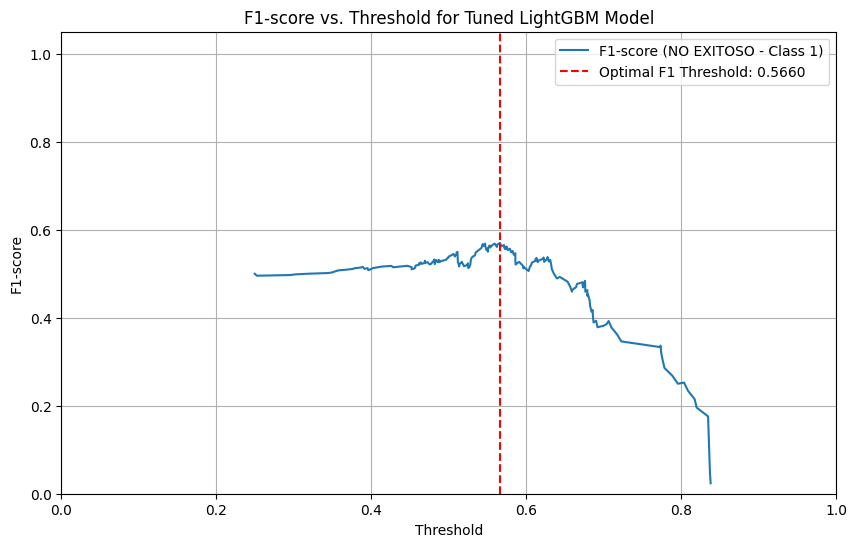

In [35]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

# Calculate F1-scores for each threshold
f1_scores_lgbm = 2 * (precisions_lgbm * recalls_lgbm) / (precisions_lgbm + recalls_lgbm)

# Find the optimal threshold (where F1-score is maximized)
optimal_threshold_idx_lgbm = np.argmax(f1_scores_lgbm)
optimal_f1_threshold_lgbm = thresholds_lgbm[optimal_threshold_idx_lgbm]

print(f"Optimal F1-score threshold: {optimal_f1_threshold_lgbm:.4f}")

# Plot F1-score vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds_lgbm, f1_scores_lgbm[:-1], label='F1-score (NO EXITOSO - Class 1)')
plt.axvline(x=optimal_f1_threshold_lgbm, color='r', linestyle='--', label=f'Optimal F1 Threshold: {optimal_f1_threshold_lgbm:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs. Threshold for Tuned LightGBM Model')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

In [36]:
# Evaluate the best LightGBM model on the test set with the optimal F1-score threshold
y_pred_at_optimal_f1_threshold_lgbm = (y_pred_proba_lgbm >= optimal_f1_threshold_lgbm).astype(int)

print(f"--- Tuned LightGBM Model Evaluation (EV Data) - TEST SET with Optimal F1 Threshold = {optimal_f1_threshold_lgbm:.4f} ---")
print(f"ROC AUC Score: {roc_auc_score(y_test_ev, y_pred_proba_lgbm):.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ev, y_pred_at_optimal_f1_threshold_lgbm):.4f}")
print("\nClassification Report:\n", classification_report(y_test_ev, y_pred_at_optimal_f1_threshold_lgbm))

--- Tuned LightGBM Model Evaluation (EV Data) - TEST SET with Optimal F1 Threshold = 0.5660 ---
ROC AUC Score: 0.7063
Accuracy Score: 0.6787

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.70      0.74       166
           1       0.51      0.64      0.57        83

    accuracy                           0.68       249
   macro avg       0.65      0.67      0.66       249
weighted avg       0.70      0.68      0.69       249



In [37]:
# Evaluate the best LightGBM model on the TRAINING set with the optimal F1-score threshold
y_train_pred_at_optimal_f1_threshold_lgbm = (y_pred_proba_lgbm_train >= optimal_f1_threshold_lgbm).astype(int)

print(f"--- Tuned LightGBM Model Evaluation (EV Data) - TRAINING SET with Optimal F1 Threshold = {optimal_f1_threshold_lgbm:.4f} ---")
print(f"ROC AUC Score: {roc_auc_score(y_train_ev, y_pred_proba_lgbm_train):.4f}")
print(f"Accuracy Score: {accuracy_score(y_train_ev, y_train_pred_at_optimal_f1_threshold_lgbm):.4f}")
print("\nClassification Report:\n", classification_report(y_train_ev, y_train_pred_at_optimal_f1_threshold_lgbm))

--- Tuned LightGBM Model Evaluation (EV Data) - TRAINING SET with Optimal F1 Threshold = 0.5660 ---
ROC AUC Score: 0.8413
Accuracy Score: 0.7553

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.78      0.81       663
           1       0.62      0.70      0.66       330

    accuracy                           0.76       993
   macro avg       0.73      0.74      0.73       993
weighted avg       0.77      0.76      0.76       993



### New Experiment: Lasso Model Training for `df_ice` Data

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Data Preparation for df_ice ---

# Define features (X_ice) and target (y_ice)
X_ice = df_ice.drop(columns=['RAZON', 'TM', 'FIn', 'Fter']) # Drop TM as it's constant, FIn/Fter as datetime
y_ice = df_ice['RAZON'].map({'NO EXITOSO': 1, 'EXITOSO': 0})

# Identify categorical and numerical columns for preprocessing
numeric_features_ice = X_ice.select_dtypes(include=['number']).columns.tolist()
categorical_features_ice = X_ice.select_dtypes(include=['object', 'category']).columns.tolist()

# Create a preprocessor using ColumnTransformer
preprocessor_ice = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_ice),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_ice)
    ])

# Split data into training and testing sets
X_train_ice, X_test_ice, y_train_ice, y_test_ice = train_test_split(X_ice, y_ice, test_size=0.2, random_state=42, stratify=y_ice)

print(f"Shape of X_train_ice: {X_train_ice.shape}")
print(f"Shape of X_test_ice: {X_test_ice.shape}")
print(f"Value counts of y_train_ice:\n{y_train_ice.value_counts()}")
print(f"Value counts of y_test_ice:\n{y_test_ice.value_counts()}")

Shape of X_train_ice: (1163, 13)
Shape of X_test_ice: (291, 13)
Value counts of y_train_ice:
RAZON
0    878
1    285
Name: count, dtype: int64
Value counts of y_test_ice:
RAZON
0    220
1     71
Name: count, dtype: int64


In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid for Lasso (Logistic Regression with L1 penalty) for ICE data
param_grid_lasso_ice = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 4}, {0: 1, 1: 5}, {0: 1, 1: 6}]
}

# Create the Lasso pipeline for ICE data
lasso_pipeline_for_tuning_ice = Pipeline(steps=[
    ('preprocessor', preprocessor_ice),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000))
])

# Set up GridSearchCV to optimize for 'recall' for the positive class (1: 'NO EXITOSO')
grid_search_lasso_ice = GridSearchCV(
    lasso_pipeline_for_tuning_ice,
    param_grid=param_grid_lasso_ice,
    cv=5, # 5-fold cross-validation
    scoring='recall', # Optimize for recall
    n_jobs=-1, # Use all available cores
    verbose=2
)

print("Starting GridSearchCV for Lasso on ICE data...")
grid_search_lasso_ice.fit(X_train_ice, y_train_ice)
print("GridSearchCV for Lasso on ICE data completed.")

# Get the best model
best_lasso_model_ice = grid_search_lasso_ice.best_estimator_

print(f"\nBest parameters found for ICE Lasso model: {grid_search_lasso_ice.best_params_}")
print(f"Best cross-validation recall score for ICE Lasso model: {grid_search_lasso_ice.best_score_:.4f}")

# Evaluate the best model on the test set
y_pred_proba_best_lasso_ice = best_lasso_model_ice.predict_proba(X_test_ice)[:, 1]
y_pred_best_lasso_ice = best_lasso_model_ice.predict(X_test_ice)

print("\n--- Tuned Lasso Model Evaluation (ICE Data) - 'NO EXITOSO' as Positive Class ---")
print(f"ROC AUC Score: {roc_auc_score(y_test_ice, y_pred_proba_best_lasso_ice):.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ice, y_pred_best_lasso_ice):.4f}")
print("\nClassification Report:\n", classification_report(y_test_ice, y_pred_best_lasso_ice))

# Display first few probability predictions
print("\nFirst 10 probability predictions (Probability of 'NO EXITOSO') from Tuned ICE Model:")
for i in range(10):
    print(f"Actual (0=EXITOSO, 1=NO EXITOSO): {y_test_ice.iloc[i]}, Predicted Probability: {y_pred_proba_best_lasso_ice[i]:.4f}")

Starting GridSearchCV for Lasso on ICE data...
Fitting 5 folds for each of 42 candidates, totalling 210 fits
GridSearchCV for Lasso on ICE data completed.

Best parameters found for ICE Lasso model: {'classifier__C': 0.01, 'classifier__class_weight': {0: 1, 1: 6}}
Best cross-validation recall score for ICE Lasso model: 0.9684

--- Tuned Lasso Model Evaluation (ICE Data) - 'NO EXITOSO' as Positive Class ---
ROC AUC Score: 0.6807
Accuracy Score: 0.3127

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.10      0.19       220
           1       0.26      0.96      0.40        71

    accuracy                           0.31       291
   macro avg       0.57      0.53      0.30       291
weighted avg       0.73      0.31      0.24       291


First 10 probability predictions (Probability of 'NO EXITOSO') from Tuned ICE Model:
Actual (0=EXITOSO, 1=NO EXITOSO): 0, Predicted Probability: 0.6129
Actual (0=EXITOSO, 1=NO EXITOSO): 1, Pre

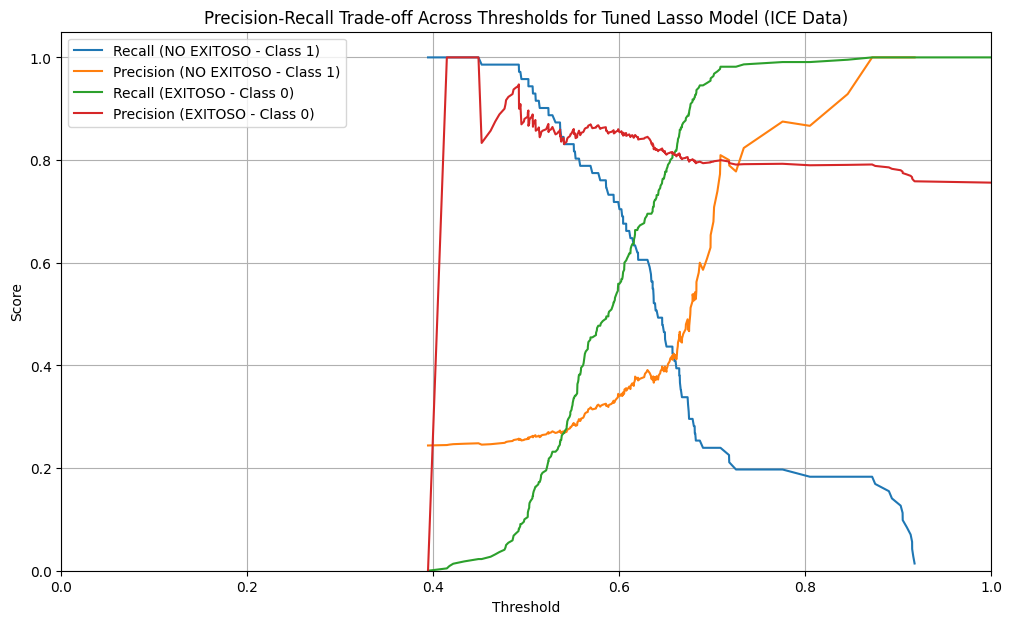

In [40]:
from sklearn.metrics import precision_recall_curve, roc_auc_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities for the positive class (1: 'NO EXITOSO') from the best Lasso model
y_pred_proba_ice = best_lasso_model_ice.predict_proba(X_test_ice)[:, 1]

# Calculate precision, recall, and thresholds for the positive class (NO EXITOSO)
precisions_ice, recalls_ice, thresholds_ice = precision_recall_curve(y_test_ice, y_pred_proba_ice, pos_label=1)

# To analyze the trade-off, we can also calculate metrics for the negative class (EXITOSO)
# This requires re-calculating predictions for each threshold.

thresholds_extended_ice = np.append(thresholds_ice, 1.0) # Add 1.0 to thresholds to include all predictions

precision_0_ice = []
recall_0_ice = []

for t in thresholds_extended_ice:
    y_pred_at_t_ice = (y_pred_proba_ice >= t).astype(int)

    true_negatives_ice = np.sum((y_test_ice == 0) & (y_pred_at_t_ice == 0))
    false_positives_ice = np.sum((y_test_ice == 0) & (y_pred_at_t_ice == 1))
    false_negatives_ice = np.sum((y_test_ice == 1) & (y_pred_at_t_ice == 0))
    true_positives_ice = np.sum((y_test_ice == 1) & (y_pred_at_t_ice == 1))

    precision_class_0_ice = true_negatives_ice / (true_negatives_ice + false_negatives_ice) if (true_negatives_ice + false_negatives_ice) > 0 else 0
    recall_class_0_ice = true_negatives_ice / (true_negatives_ice + false_positives_ice) if (true_negatives_ice + false_positives_ice) > 0 else 0

    precision_0_ice.append(precision_class_0_ice)
    recall_0_ice.append(recall_class_0_ice)

# Plotting
plt.figure(figsize=(12, 7))
plt.plot(thresholds_ice, recalls_ice[:-1], label='Recall (NO EXITOSO - Class 1)')
plt.plot(thresholds_ice, precisions_ice[:-1], label='Precision (NO EXITOSO - Class 1)')
plt.plot(thresholds_extended_ice, np.array(recall_0_ice), label='Recall (EXITOSO - Class 0)')
plt.plot(thresholds_extended_ice, np.array(precision_0_ice), label='Precision (EXITOSO - Class 0)')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off Across Thresholds for Tuned Lasso Model (ICE Data)')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

### Tuned Lasso Model Evaluation (ICE Data) with Specific Threshold = 0.56 (Train and Test)

In [41]:
threshold = 0.5875

# --- Evaluation for Training Set with new threshold ---
print(f"--- Tuned Lasso Model Evaluation (ICE Data) - TRAINING SET with Threshold = {threshold} ---")
# Get probabilities for the positive class (1: 'NO EXITOSO') from the best Lasso model
y_pred_proba_ice_train = best_lasso_model_ice.predict_proba(X_train_ice)[:, 1]

# Apply the specified threshold to get binary predictions
y_pred_at_threshold_ice_train = (y_pred_proba_ice_train >= threshold).astype(int)

print(f"ROC AUC Score: {roc_auc_score(y_train_ice, y_pred_proba_ice_train):.4f}")
print(f"Accuracy Score: {accuracy_score(y_train_ice, y_pred_at_threshold_ice_train):.4f}")
print("\nClassification Report:\n", classification_report(y_train_ice, y_pred_at_threshold_ice_train))

print("\n" + "="*70 + "\n")

# --- Evaluation for Test Set with new threshold ---
print(f"--- Tuned Lasso Model Evaluation (ICE Data) - TEST SET with Threshold = {threshold} ---")
# Get probabilities for the positive class (1: 'NO EXITOSO') from the best Lasso model
y_pred_proba_ice_test = best_lasso_model_ice.predict_proba(X_test_ice)[:, 1]

# Apply the specified threshold to get binary predictions
y_pred_at_threshold_ice_test = (y_pred_proba_ice_test >= threshold).astype(int)

print(f"ROC AUC Score: {roc_auc_score(y_test_ice, y_pred_proba_ice_test):.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ice, y_pred_at_threshold_ice_test):.4f}")
print("\nClassification Report:\n", classification_report(y_test_ice, y_pred_at_threshold_ice_test))

--- Tuned Lasso Model Evaluation (ICE Data) - TRAINING SET with Threshold = 0.5875 ---
ROC AUC Score: 0.6926
Accuracy Score: 0.5684

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.53      0.65       878
           1       0.32      0.70      0.44       285

    accuracy                           0.57      1163
   macro avg       0.58      0.61      0.55      1163
weighted avg       0.72      0.57      0.60      1163



--- Tuned Lasso Model Evaluation (ICE Data) - TEST SET with Threshold = 0.5875 ---
ROC AUC Score: 0.6807
Accuracy Score: 0.5533

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.50      0.63       220
           1       0.32      0.73      0.44        71

    accuracy                           0.55       291
   macro avg       0.59      0.61      0.54       291
weighted avg       0.72      0.55      0.58       291



### Threshold Optimization for Lasso using F1-score (ICE Data)

Optimal F1-score threshold for Lasso model (ICE Data): 0.6303


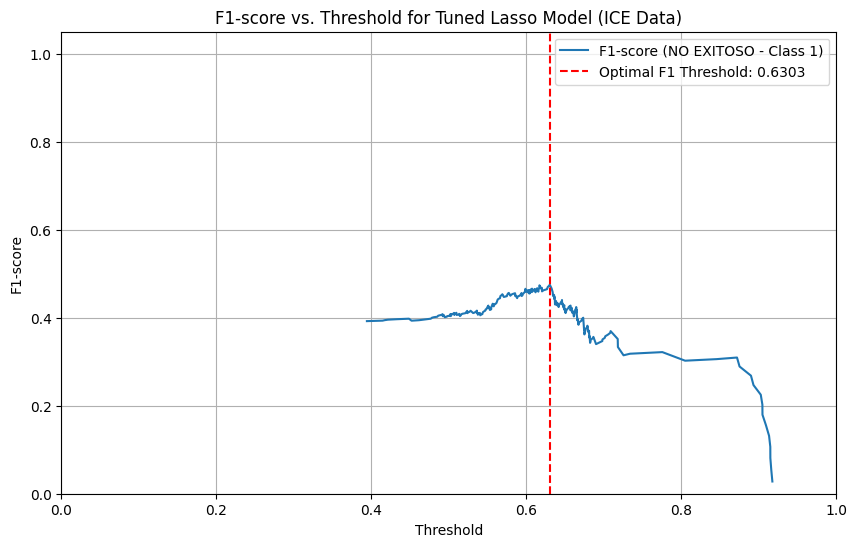

In [42]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

# Reuse precisions, recalls, and thresholds calculated in cell 32db9f0c for the Lasso model on ICE data
# y_pred_proba_ice was already calculated

# Calculate F1-scores for each threshold
f1_scores_lasso_ice = 2 * (precisions_ice * recalls_ice) / (precisions_ice + recalls_ice)

# Find the optimal threshold (where F1-score is maximized)
optimal_threshold_idx_lasso_ice = np.argmax(f1_scores_lasso_ice)
optimal_f1_threshold_lasso_ice = thresholds_ice[optimal_threshold_idx_lasso_ice]

print(f"Optimal F1-score threshold for Lasso model (ICE Data): {optimal_f1_threshold_lasso_ice:.4f}")

# Plot F1-score vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds_ice, f1_scores_lasso_ice[:-1], label='F1-score (NO EXITOSO - Class 1)')
plt.axvline(x=optimal_f1_threshold_lasso_ice, color='r', linestyle='--', label=f'Optimal F1 Threshold: {optimal_f1_threshold_lasso_ice:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs. Threshold for Tuned Lasso Model (ICE Data)')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

In [43]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, f1_score, precision_score, recall_score
import numpy as np

# Get probabilities for the positive class (1: 'NO EXITOSO') from the best Lasso model for ICE data
y_pred_proba_lasso_ice_test = best_lasso_model_ice.predict_proba(X_test_ice)[:, 1]

# Apply the optimal F1-score threshold to get binary predictions
y_pred_at_optimal_f1_threshold_lasso_ice_eval = (y_pred_proba_lasso_ice_test >= optimal_f1_threshold_lasso_ice).astype(int)

# Calculate metrics
roc_auc_ice_lasso = roc_auc_score(y_test_ice, y_pred_proba_lasso_ice_test)
accuracy_ice_lasso = accuracy_score(y_test_ice, y_pred_at_optimal_f1_threshold_lasso_ice_eval)
report_ice_lasso = classification_report(y_test_ice, y_pred_at_optimal_f1_threshold_lasso_ice_eval, output_dict=True)

recall_1_ice_lasso = report_ice_lasso['1']['recall']
precision_0_ice_lasso = report_ice_lasso['0']['precision']
f1_1_ice_lasso = report_ice_lasso['1']['f1-score']

print(f"--- Tuned Lasso Model Evaluation (ICE Data) - TEST SET with Optimal F1 Threshold = {optimal_f1_threshold_lasso_ice:.4f} ---")
print(f"ROC AUC Score: {roc_auc_ice_lasso:.4f}")
print(f"Accuracy Score: {accuracy_ice_lasso:.4f}")
print(f"Recall (Class 1 - NO EXITOSO): {recall_1_ice_lasso:.4f}")
print(f"Precision (Class 0 - EXITOSO): {precision_0_ice_lasso:.4f}")
print(f"F1-score (Class 1 - NO EXITOSO): {f1_1_ice_lasso:.4f}")
print("\nClassification Report:\n", classification_report(y_test_ice, y_pred_at_optimal_f1_threshold_lasso_ice_eval))

--- Tuned Lasso Model Evaluation (ICE Data) - TEST SET with Optimal F1 Threshold = 0.6303 ---
ROC AUC Score: 0.6807
Accuracy Score: 0.6735
Recall (Class 1 - NO EXITOSO): 0.6056
Precision (Class 0 - EXITOSO): 0.8453
F1-score (Class 1 - NO EXITOSO): 0.4751

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.70      0.76       220
           1       0.39      0.61      0.48        71

    accuracy                           0.67       291
   macro avg       0.62      0.65      0.62       291
weighted avg       0.73      0.67      0.69       291



In [44]:
import pandas as pd

# Prepare the data for the table
data = {
    'Model': ['Lasso', 'Lasso', 'LightGBM'],
    'TM': ['EV', 'ICE', 'EV'],
    'Optimal F1-score Threshold': [
        optimal_f1_threshold_lasso,
        optimal_f1_threshold_lasso_ice,
        optimal_f1_threshold_lgbm
    ]
}

thresholds_df = pd.DataFrame(data)

print("Umbrales óptimos de F1-score por modelo y tipo de motor (TM):")
display(thresholds_df)


Umbrales óptimos de F1-score por modelo y tipo de motor (TM):


,Model,TM,Optimal F1-score Threshold
0,Lasso,EV,0.578531
1,Lasso,ICE,0.630324
2,LightGBM,EV,0.566049


### New Experiment: LightGBM Model Training for `df_ice` Data

In [45]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Define the parameter grid for LightGBM (ICE data)
param_grid_lgbm_ice = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 8, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__num_leaves': [20, 31, 40], # Number of leaves in one tree
    'classifier__class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}] # Handling class imbalance
}

# Create the LightGBM pipeline for tuning (re-using preprocessor_ice)
lgbm_pipeline_for_tuning_ice = Pipeline(steps=[
    ('preprocessor', preprocessor_ice),
    ('classifier', lgb.LGBMClassifier(random_state=42, n_jobs=-1))
])

# Set up GridSearchCV to optimize for 'recall' of the positive class (1: 'NO EXITOSO')
grid_search_lgbm_ice = GridSearchCV(
    lgbm_pipeline_for_tuning_ice,
    param_grid=param_grid_lgbm_ice,
    cv=5, # 5-fold cross-validation
    scoring='recall', # Optimize for recall
    n_jobs=-1, # Use all available cores
    verbose=2
)

print("Starting GridSearchCV for LightGBM on ICE data...")
grid_search_lgbm_ice.fit(X_train_ice, y_train_ice)
print("GridSearchCV for LightGBM on ICE data completed.")

# Get the best model
best_lgbm_model_ice = grid_search_lgbm_ice.best_estimator_

print(f"\nBest parameters found for ICE LightGBM model: {grid_search_lgbm_ice.best_params_}")
print(f"Best cross-validation recall score for ICE LightGBM model: {grid_search_lgbm_ice.best_score_:.4f}")

# --- Evaluate the best model on the TRAINING set ---
print("\n--- Tuned LightGBM Model Evaluation (ICE Data) - TRAINING SET ---")
y_train_pred_proba_best_lgbm_ice = best_lgbm_model_ice.predict_proba(X_train_ice)[:, 1]
y_train_pred_best_lgbm_ice = best_lgbm_model_ice.predict(X_train_ice)

print(f"ROC AUC Score (Train): {roc_auc_score(y_train_ice, y_train_pred_proba_best_lgbm_ice):.4f}")
print(f"Accuracy Score (Train): {accuracy_score(y_train_ice, y_train_pred_best_lgbm_ice):.4f}")
print("\nClassification Report (Training Set):\n", classification_report(y_train_ice, y_train_pred_best_lgbm_ice))

print("\n" + "="*70 + "\n")

# --- Evaluate the best model on the TEST set ---
print("--- Tuned LightGBM Model Evaluation (ICE Data) - TEST SET ---")
y_test_pred_proba_best_lgbm_ice = best_lgbm_model_ice.predict_proba(X_test_ice)[:, 1]
y_test_pred_best_lgbm_ice = best_lgbm_model_ice.predict(X_test_ice)

print(f"ROC AUC Score (Test): {roc_auc_score(y_test_ice, y_test_pred_proba_best_lgbm_ice):.4f}")
print(f"Accuracy Score (Test): {accuracy_score(y_test_ice, y_test_pred_best_lgbm_ice):.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ice, y_test_pred_best_lgbm_ice))

Starting GridSearchCV for LightGBM on ICE data...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Info] Number of positive: 285, number of negative: 878
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000307 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1627
[LightGBM] [Info] Number of data points in the train set: 1163, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Random Forest Model Training for `df_ice`

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Create the Random Forest model pipeline (re-using preprocessor_ice)
rf_model_ice = Pipeline(steps=[
    ('preprocessor', preprocessor_ice),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("Training Random Forest model for ICE data...")
# Train the model
rf_model_ice.fit(X_train_ice, y_train_ice)
print("Random Forest model training completed.")

# --- Evaluate on Training Set ---
print("\n--- Random Forest Model Evaluation (ICE Data) - TRAINING SET ---")
y_train_pred_proba_rf_ice = rf_model_ice.predict_proba(X_train_ice)[:, 1]
y_train_pred_rf_ice = rf_model_ice.predict(X_train_ice)

print(f"ROC AUC Score (Train): {roc_auc_score(y_train_ice, y_train_pred_proba_rf_ice):.4f}")
print(f"Accuracy Score (Train): {accuracy_score(y_train_ice, y_train_pred_rf_ice):.4f}")
print("\nClassification Report (Training Set):\n", classification_report(y_train_ice, y_train_pred_rf_ice))

print("\n" + "="*70 + "\n")

# --- Evaluate on Test Set ---
print("--- Random Forest Model Evaluation (ICE Data) - TEST SET ---")
y_test_pred_proba_rf_ice = rf_model_ice.predict_proba(X_test_ice)[:, 1]
y_test_pred_rf_ice = rf_model_ice.predict(X_test_ice)

print(f"ROC AUC Score (Test): {roc_auc_score(y_test_ice, y_test_pred_proba_rf_ice):.4f}")
print(f"Accuracy Score (Test): {accuracy_score(y_test_ice, y_test_pred_rf_ice):.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ice, y_test_pred_rf_ice))

Training Random Forest model for ICE data...
Random Forest model training completed.

--- Random Forest Model Evaluation (ICE Data) - TRAINING SET ---
ROC AUC Score (Train): 1.0000
Accuracy Score (Train): 1.0000

Classification Report (Training Set):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       878
           1       1.00      1.00      1.00       285

    accuracy                           1.00      1163
   macro avg       1.00      1.00      1.00      1163
weighted avg       1.00      1.00      1.00      1163



--- Random Forest Model Evaluation (ICE Data) - TEST SET ---
ROC AUC Score (Test): 0.7282
Accuracy Score (Test): 0.8007

Classification Report (Test Set):
               precision    recall  f1-score   support

           0       0.82      0.94      0.88       220
           1       0.67      0.37      0.47        71

    accuracy                           0.80       291
   macro avg       0.74      0.65      0.67  

### Hyperparameter Tuning for Random Forest Model (`df_ice`) using GridSearchCV

### Hyperparameter Tuning v2 for Random Forest Model (`df_ice`) - More Aggressive Overfitting Reduction

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Define the updated parameter grid for RandomForestClassifier (v2) - More aggressive regularization
param_grid_rf_ice_v2 = {
    'classifier__n_estimators': [100, 200], # Fewer estimators
    'classifier__max_depth': [5, 8],   # Reduced maximum depth values
    'classifier__min_samples_leaf': [10, 20], # Increased minimum samples per leaf significantly
    'classifier__min_samples_split': [2, 5], # Increased minimum samples to split
    'classifier__ccp_alpha': [0.0, 0.001, 0.005], # Cost-complexity pruning parameter
    'classifier__class_weight': ['balanced', {0: 1, 1: 2}] # Focus on balanced or slightly weighted
}

# Create the Random Forest pipeline for tuning (re-using preprocessor_ice)
rf_pipeline_for_tuning_ice_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor_ice),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Set up GridSearchCV to optimize for 'recall' of the positive class (1: 'NO EXITOSO')
grid_search_rf_ice_v2 = GridSearchCV(
    rf_pipeline_for_tuning_ice_v2,
    param_grid=param_grid_rf_ice_v2,
    cv=5, # 5-fold cross-validation
    scoring='recall', # Optimize for recall
    n_jobs=-1, # Use all available cores
    verbose=2
)

print("Starting GridSearchCV v2 for Random Forest on ICE data (focus on reducing overfitting)...")
grid_search_rf_ice_v2.fit(X_train_ice, y_train_ice)
print("GridSearchCV v2 for Random Forest on ICE data completed.")

# Get the best model from the second tuning phase
best_rf_model_ice_v2 = grid_search_rf_ice_v2.best_estimator_

print(f"\nBest parameters found (v2): {grid_search_rf_ice_v2.best_params_}")
print(f"Best cross-validation recall score (v2): {grid_search_rf_ice_v2.best_score_:.4f}")

# --- Evaluate the best model (v2) on the TRAINING set ---
print("\n--- Tuned Random Forest Model Evaluation v2 (ICE Data) - TRAINING SET ---")
y_train_pred_proba_best_rf_ice_v2 = best_rf_model_ice_v2.predict_proba(X_train_ice)[:, 1]
y_train_pred_best_rf_ice_v2 = best_rf_model_ice_v2.predict(X_train_ice)

print(f"ROC AUC Score (Train): {roc_auc_score(y_train_ice, y_train_pred_proba_best_rf_ice_v2):.4f}")
print(f"Accuracy Score (Train): {accuracy_score(y_train_ice, y_train_pred_best_rf_ice_v2):.4f}")
print("\nClassification Report (Training Set):\n", classification_report(y_train_ice, y_train_pred_best_rf_ice_v2))

print("\n" + "="*70 + "\n")

# --- Evaluate the best model (v2) on the TEST set ---
print("--- Tuned Random Forest Model Evaluation v2 (ICE Data) - TEST SET ---")
y_test_pred_proba_best_rf_ice_v2 = best_rf_model_ice_v2.predict_proba(X_test_ice)[:, 1]
y_test_pred_best_rf_ice_v2 = best_rf_model_ice_v2.predict(X_test_ice)

print(f"ROC AUC Score (Test): {roc_auc_score(y_test_ice, y_test_pred_proba_best_rf_ice_v2):.4f}")
print(f"Accuracy Score (Test): {accuracy_score(y_test_ice, y_test_pred_best_rf_ice_v2):.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ice, y_test_pred_best_rf_ice_v2))

Starting GridSearchCV v2 for Random Forest on ICE data (focus on reducing overfitting)...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
GridSearchCV v2 for Random Forest on ICE data completed.

Best parameters found (v2): {'classifier__ccp_alpha': 0.0, 'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best cross-validation recall score (v2): 0.6246

--- Tuned Random Forest Model Evaluation v2 (ICE Data) - TRAINING SET ---
ROC AUC Score (Train): 0.7879
Accuracy Score (Train): 0.6922

Classification Report (Training Set):
               precision    recall  f1-score   support

           0       0.90      0.67      0.77       878
           1       0.43      0.76      0.55       285

    accuracy                           0.69      1163
   macro avg       0.66      0.72      0.66      1163
weighted avg       0.78      0.69      0.71      1163



--- T

### Threshold Optimization for Random Forest: Precision-Recall Trade-off (ICE Data - v2)

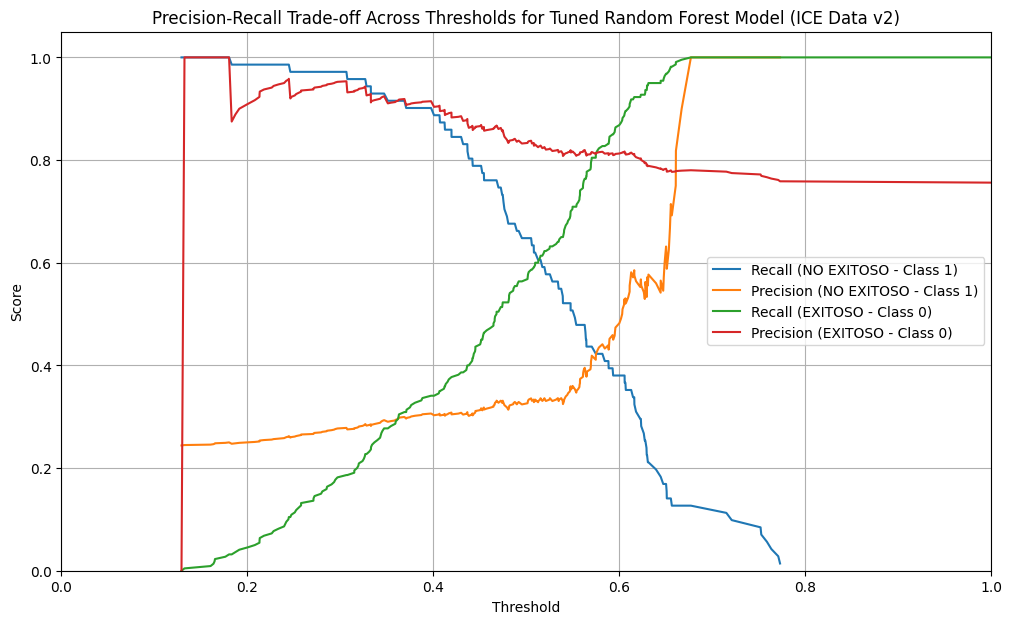

In [48]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities for the positive class (1: 'NO EXITOSO') from the best Random Forest model for ICE data (v2)
y_pred_proba_rf_ice_v2 = best_rf_model_ice_v2.predict_proba(X_test_ice)[:, 1]

# Calculate precision, recall, and thresholds for the positive class (NO EXITOSO)
precisions_rf_ice_v2, recalls_rf_ice_v2, thresholds_rf_ice_v2 = precision_recall_curve(y_test_ice, y_pred_proba_rf_ice_v2, pos_label=1)

# To analyze the trade-off, we can also calculate metrics for the negative class (EXITOSO)
thresholds_extended_rf_ice_v2 = np.append(thresholds_rf_ice_v2, 1.0) # Add 1.0 to thresholds to include all predictions

precision_0_rf_ice_v2 = []
recall_0_rf_ice_v2 = []

for t in thresholds_extended_rf_ice_v2:
    y_pred_at_t_rf_ice_v2 = (y_pred_proba_rf_ice_v2 >= t).astype(int)

    true_negatives_rf_ice_v2 = np.sum((y_test_ice == 0) & (y_pred_at_t_rf_ice_v2 == 0))
    false_positives_rf_ice_v2 = np.sum((y_test_ice == 0) & (y_pred_at_t_rf_ice_v2 == 1))
    false_negatives_rf_ice_v2 = np.sum((y_test_ice == 1) & (y_pred_at_t_rf_ice_v2 == 0))
    true_positives_rf_ice_v2 = np.sum((y_test_ice == 1) & (y_pred_at_t_rf_ice_v2 == 1))

    precision_class_0_rf_ice_v2 = true_negatives_rf_ice_v2 / (true_negatives_rf_ice_v2 + false_negatives_rf_ice_v2) if (true_negatives_rf_ice_v2 + false_negatives_rf_ice_v2) > 0 else 0
    recall_class_0_rf_ice_v2 = true_negatives_rf_ice_v2 / (true_negatives_rf_ice_v2 + false_positives_rf_ice_v2) if (true_negatives_rf_ice_v2 + false_positives_rf_ice_v2) > 0 else 0

    precision_0_rf_ice_v2.append(precision_class_0_rf_ice_v2)
    recall_0_rf_ice_v2.append(recall_class_0_rf_ice_v2)

# Plotting
plt.figure(figsize=(12, 7))
plt.plot(thresholds_rf_ice_v2, recalls_rf_ice_v2[:-1], label='Recall (NO EXITOSO - Class 1)')
plt.plot(thresholds_rf_ice_v2, precisions_rf_ice_v2[:-1], label='Precision (NO EXITOSO - Class 1)')
plt.plot(thresholds_extended_rf_ice_v2, np.array(recall_0_rf_ice_v2), label='Recall (EXITOSO - Class 0)')
plt.plot(thresholds_extended_rf_ice_v2, np.array(precision_0_rf_ice_v2), label='Precision (EXITOSO - Class 0)')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off Across Thresholds for Tuned Random Forest Model (ICE Data v2)')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

### Threshold Optimization for Random Forest using F1-score (ICE Data - v2)

Optimal F1-score threshold for Random Forest model (ICE Data v2): 0.4681


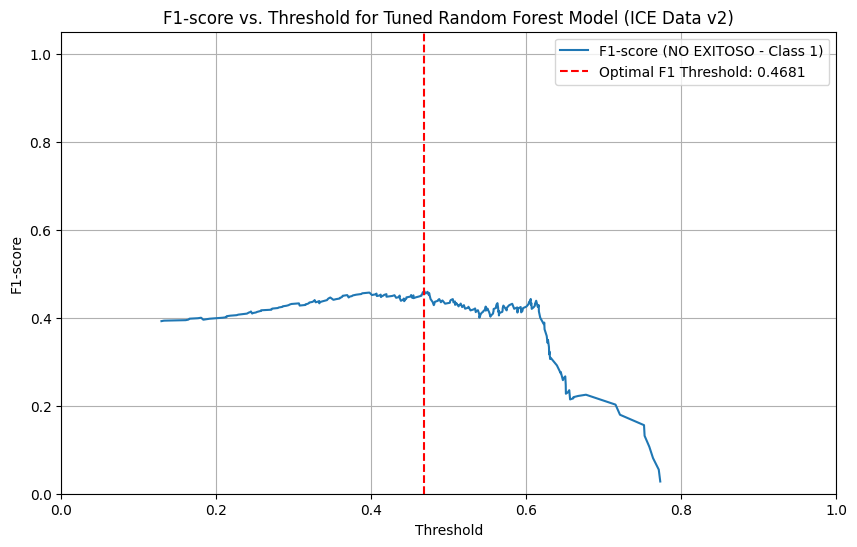

In [49]:
from sklearn.metrics import f1_score

# Calculate F1-scores for each threshold
f1_scores_rf_ice_v2 = 2 * (precisions_rf_ice_v2 * recalls_rf_ice_v2) / (precisions_rf_ice_v2 + recalls_rf_ice_v2)

# Find the optimal threshold (where F1-score is maximized)
optimal_threshold_idx_rf_ice_v2 = np.argmax(f1_scores_rf_ice_v2)
optimal_f1_threshold_rf_ice_v2 = thresholds_rf_ice_v2[optimal_threshold_idx_rf_ice_v2]

print(f"Optimal F1-score threshold for Random Forest model (ICE Data v2): {optimal_f1_threshold_rf_ice_v2:.4f}")

# Plot F1-score vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds_rf_ice_v2, f1_scores_rf_ice_v2[:-1], label='F1-score (NO EXITOSO - Class 1)')
plt.axvline(x=optimal_f1_threshold_rf_ice_v2, color='r', linestyle='--', label=f'Optimal F1 Threshold: {optimal_f1_threshold_rf_ice_v2:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs. Threshold for Tuned Random Forest Model (ICE Data v2)')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

In [50]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, f1_score, precision_score, recall_score

# Evaluate the best Random Forest model (v2) on the test set with the optimal F1-score threshold
y_test_pred_at_optimal_f1_threshold_rf_ice_v2 = (y_pred_proba_rf_ice_v2 >= optimal_f1_threshold_rf_ice_v2).astype(int)

roc_auc_ice_rf_v2 = roc_auc_score(y_test_ice, y_pred_proba_rf_ice_v2)
report_ice_rf_v2 = classification_report(y_test_ice, y_test_pred_at_optimal_f1_threshold_rf_ice_v2, output_dict=True)
recall_1_ice_rf_v2 = report_ice_rf_v2['1']['recall']
precision_0_ice_rf_v2 = report_ice_rf_v2['0']['precision']
f1_1_ice_rf_v2 = report_ice_rf_v2['1']['f1-score']

print(f"--- Tuned Random Forest Model Evaluation (ICE Data v2) - TEST SET with Optimal F1 Threshold = {optimal_f1_threshold_rf_ice_v2:.4f} ---")
print(f"ROC AUC Score: {roc_auc_ice_rf_v2:.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ice, y_test_pred_at_optimal_f1_threshold_rf_ice_v2):.4f}")
print(f"Recall (Class 1 - NO EXITOSO): {recall_1_ice_rf_v2:.4f}")
print(f"Precision (Class 0 - EXITOSO): {precision_0_ice_rf_v2:.4f}")
print(f"F1-score (Class 1 - NO EXITOSO): {f1_1_ice_rf_v2:.4f}")
print("\nClassification Report:\n", classification_report(y_test_ice, y_test_pred_at_optimal_f1_threshold_rf_ice_v2))

--- Tuned Random Forest Model Evaluation (ICE Data v2) - TEST SET with Optimal F1 Threshold = 0.4681 ---
ROC AUC Score: 0.6859
Accuracy Score: 0.5670
Recall (Class 1 - NO EXITOSO): 0.7606
Precision (Class 0 - EXITOSO): 0.8672
F1-score (Class 1 - NO EXITOSO): 0.4615

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.50      0.64       220
           1       0.33      0.76      0.46        71

    accuracy                           0.57       291
   macro avg       0.60      0.63      0.55       291
weighted avg       0.74      0.57      0.59       291



### Evaluating Overfitting for Tuned Random Forest Model (EV Data v5)

In [51]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# --- Evaluate the best Random Forest model (v5) on the TRAINING set (EV Data) ---
print("--- Tuned Random Forest Model Evaluation v5 (EV Data) - TRAINING SET ---")
y_train_pred_proba_best_rf_ev_v5 = best_rf_model_ev_v5.predict_proba(X_train_ev)[:, 1]
y_train_pred_best_rf_ev_v5 = best_rf_model_ev_v5.predict(X_train_ev)

roc_auc_ev_rf_train = roc_auc_score(y_train_ev, y_train_pred_proba_best_rf_ev_v5)
report_ev_rf_train = classification_report(y_train_ev, y_train_pred_best_rf_ev_v5, output_dict=True)
recall_1_ev_rf_train = report_ev_rf_train['1']['recall']
precision_0_ev_rf_train = report_ev_rf_train['0']['precision']
f1_1_ev_rf_train = report_ev_rf_train['1']['f1-score']

print(f"ROC AUC Score (Train): {roc_auc_ev_rf_train:.4f}")
print(f"Accuracy Score (Train): {accuracy_score(y_train_ev, y_train_pred_best_rf_ev_v5):.4f}")
print(f"Recall (Class 1 - NO EXITOSO, Train): {recall_1_ev_rf_train:.4f}")
print(f"Precision (Class 0 - EXITOSO, Train): {precision_0_ev_rf_train:.4f}")
print(f"F1-score (Class 1 - NO EXITOSO, Train): {f1_1_ev_rf_train:.4f}")
print("\nClassification Report (Training Set):\n", classification_report(y_train_ev, y_train_pred_best_rf_ev_v5))

print("\n" + "="*70 + "\n")

# --- Evaluate the best Random Forest model (v5) on the TEST set (EV Data) ---
print("--- Tuned Random Forest Model Evaluation v5 (EV Data) - TEST SET ---")
y_test_pred_proba_best_rf_ev_v5 = best_rf_model_ev_v5.predict_proba(X_test_ev)[:, 1]
y_test_pred_best_rf_ev_v5 = best_rf_model_ev_v5.predict(X_test_ev)

roc_auc_ev_rf_test = roc_auc_score(y_test_ev, y_test_pred_proba_best_rf_ev_v5)
report_ev_rf_test = classification_report(y_test_ev, y_test_pred_best_rf_ev_v5, output_dict=True)
recall_1_ev_rf_test = report_ev_rf_test['1']['recall']
precision_0_ev_rf_test = report_ev_rf_test['0']['precision']
f1_1_ev_rf_test = report_ev_rf_test['1']['f1-score']

print(f"ROC AUC Score (Test): {roc_auc_ev_rf_test:.4f}")
print(f"Accuracy Score (Test): {accuracy_score(y_test_ev, y_test_pred_best_rf_ev_v5):.4f}")
print(f"Recall (Class 1 - NO EXITOSO, Test): {recall_1_ev_rf_test:.4f}")
print(f"Precision (Class 0 - EXITOSO, Test): {precision_0_ev_rf_test:.4f}")
print(f"F1-score (Class 1 - NO EXITOSO, Test): {f1_1_ev_rf_test:.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ev, y_test_pred_best_rf_ev_v5))

--- Tuned Random Forest Model Evaluation v5 (EV Data) - TRAINING SET ---
ROC AUC Score (Train): 0.8552
Accuracy Score (Train): 0.7956
Recall (Class 1 - NO EXITOSO, Train): 0.7212
Precision (Class 0 - EXITOSO, Train): 0.8571
F1-score (Class 1 - NO EXITOSO, Train): 0.7010

Classification Report (Training Set):
               precision    recall  f1-score   support

           0       0.86      0.83      0.84       663
           1       0.68      0.72      0.70       330

    accuracy                           0.80       993
   macro avg       0.77      0.78      0.77       993
weighted avg       0.80      0.80      0.80       993



--- Tuned Random Forest Model Evaluation v5 (EV Data) - TEST SET ---
ROC AUC Score (Test): 0.6957
Accuracy Score (Test): 0.6466
Recall (Class 1 - NO EXITOSO, Test): 0.5422
Precision (Class 0 - EXITOSO, Test): 0.7532
F1-score (Class 1 - NO EXITOSO, Test): 0.5056

Classification Report (Test Set):
               precision    recall  f1-score   support

       

### Evaluating Overfitting for Tuned Random Forest Model (ICE Data v2)

In [52]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# --- Evaluate the best Random Forest model (v2) on the TRAINING set (ICE Data) ---
print("--- Tuned Random Forest Model Evaluation v2 (ICE Data) - TRAINING SET ---")
y_train_pred_proba_best_rf_ice_v2 = best_rf_model_ice_v2.predict_proba(X_train_ice)[:, 1]
y_train_pred_best_rf_ice_v2 = best_rf_model_ice_v2.predict(X_train_ice)

roc_auc_ice_rf_v2_train = roc_auc_score(y_train_ice, y_train_pred_proba_best_rf_ice_v2)
report_ice_rf_v2_train = classification_report(y_train_ice, y_train_pred_best_rf_ice_v2, output_dict=True)
recall_1_ice_rf_v2_train = report_ice_rf_v2_train['1']['recall']
precision_0_ice_rf_v2_train = report_ice_rf_v2_train['0']['precision']
f1_1_ice_rf_v2_train = report_ice_rf_v2_train['1']['f1-score']

print(f"ROC AUC Score (Train): {roc_auc_ice_rf_v2_train:.4f}")
print(f"Accuracy Score (Train): {accuracy_score(y_train_ice, y_train_pred_best_rf_ice_v2):.4f}")
print(f"Recall (Class 1 - NO EXITOSO, Train): {recall_1_ice_rf_v2_train:.4f}")
print(f"Precision (Class 0 - EXITOSO, Train): {precision_0_ice_rf_v2_train:.4f}")
print(f"F1-score (Class 1 - NO EXITOSO, Train): {f1_1_ice_rf_v2_train:.4f}")
print("\nClassification Report (Training Set):\n", classification_report(y_train_ice, y_train_pred_best_rf_ice_v2))

print("\n" + "="*70 + "\n")

# --- Evaluate the best Random Forest model (v2) on the TEST set (ICE Data) ---
print("--- Tuned Random Forest Model Evaluation v2 (ICE Data) - TEST SET ---")
y_test_pred_proba_best_rf_ice_v2 = best_rf_model_ice_v2.predict_proba(X_test_ice)[:, 1]
y_test_pred_best_rf_ice_v2 = best_rf_model_ice_v2.predict(X_test_ice)

roc_auc_ice_rf_v2_test = roc_auc_score(y_test_ice, y_test_pred_proba_best_rf_ice_v2)
report_ice_rf_v2_test = classification_report(y_test_ice, y_test_pred_best_rf_ice_v2, output_dict=True)
recall_1_ice_rf_v2_test = report_ice_rf_v2_test['1']['recall']
precision_0_ice_rf_v2_test = report_ice_rf_v2_test['0']['precision']
f1_1_ice_rf_v2_test = report_ice_rf_v2_test['1']['f1-score']

print(f"ROC AUC Score (Test): {roc_auc_ice_rf_v2_test:.4f}")
print(f"Accuracy Score (Test): {accuracy_score(y_test_ice, y_test_pred_best_rf_ice_v2):.4f}")
print(f"Recall (Class 1 - NO EXITOSO, Test): {recall_1_ice_rf_v2_test:.4f}")
print(f"Precision (Class 0 - EXITOSO, Test): {precision_0_ice_rf_v2_test:.4f}")
print(f"F1-score (Class 1 - NO EXITOSO, Test): {f1_1_ice_rf_v2_test:.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ice, y_test_pred_best_rf_ice_v2))

--- Tuned Random Forest Model Evaluation v2 (ICE Data) - TRAINING SET ---
ROC AUC Score (Train): 0.7879
Accuracy Score (Train): 0.6922
Recall (Class 1 - NO EXITOSO, Train): 0.7649
Precision (Class 0 - EXITOSO, Train): 0.8976
F1-score (Class 1 - NO EXITOSO, Train): 0.5491

Classification Report (Training Set):
               precision    recall  f1-score   support

           0       0.90      0.67      0.77       878
           1       0.43      0.76      0.55       285

    accuracy                           0.69      1163
   macro avg       0.66      0.72      0.66      1163
weighted avg       0.78      0.69      0.71      1163



--- Tuned Random Forest Model Evaluation v2 (ICE Data) - TEST SET ---
ROC AUC Score (Test): 0.6859
Accuracy Score (Test): 0.5876
Recall (Class 1 - NO EXITOSO, Test): 0.6479
Precision (Class 0 - EXITOSO, Test): 0.8333
F1-score (Class 1 - NO EXITOSO, Test): 0.4340

Classification Report (Test Set):
               precision    recall  f1-score   support

     

### Final Updated Summary Table of All Model Metrics (with Tuned Random Forest ICE v2)

In [53]:
import pandas as pd

# Prepare the data for the final updated table with all metrics
data_final_summary = {
    'Model': ['Lasso', 'Lasso', 'LightGBM', 'LightGBM', 'Random Forest', 'Random Forest'],
    'TM': ['EV', 'ICE', 'EV', 'ICE', 'EV', 'ICE'],
    'Optimal F1-score Threshold': [
        optimal_f1_threshold_lasso,
        optimal_f1_threshold_lasso_ice,
        optimal_f1_threshold_lgbm,
        optimal_f1_threshold_lgbm_ice,
        optimal_f1_threshold_rf_ev,
        optimal_f1_threshold_rf_ice_v2 # Updated with v2 threshold
    ],
    'ROC AUC Score': [
        roc_auc_ev_lasso,
        roc_auc_ice_lasso,
        roc_auc_ev_lgbm,
        roc_auc_ice_lgbm,
        roc_auc_ev_rf,
        roc_auc_ice_rf_v2 # Updated with v2 ROC AUC
    ],
    'Recall (Class 1 - NO EXITOSO)': [
        recall_1_ev_lasso,
        recall_1_ice_lasso,
        recall_1_ev_lgbm,
        recall_1_ice_lgbm,
        recall_1_ev_rf,
        recall_1_ice_rf_v2 # Updated with v2 recall
    ],
    'Precision (Class 0 - EXITOSO)': [
        precision_0_ev_lasso,
        precision_0_ice_lasso,
        precision_0_ev_lgbm,
        precision_0_ice_lgbm,
        precision_0_ev_rf,
        precision_0_ice_rf_v2 # Updated with v2 precision
    ],
    'F1-score (Class 1 - NO EXITOSO)': [
        f1_1_ev_lasso,
        f1_1_ice_lasso,
        f1_1_ev_lgbm,
        f1_1_ice_lgbm,
        f1_1_ev_rf,
        f1_1_ice_rf_v2 # Updated with v2 f1-score
    ]
}

metrics_summary_df_final = pd.DataFrame(data_final_summary)

print("Tabla resumen completa de métricas por modelo y tipo de motor (TM) (Actualizado con Tuned Random Forest ICE v2):")
display(metrics_summary_df_final)

NameError: name 'optimal_f1_threshold_lgbm_ice' is not defined

In [ ]:
import pandas as pd

# Prepare the data for the final updated table with all metrics
data_final_summary = {
    'Model': ['Lasso', 'Lasso', 'LightGBM', 'LightGBM', 'Random Forest', 'Random Forest'],
    'TM': ['EV', 'ICE', 'EV', 'ICE', 'EV', 'ICE'],
    'Optimal F1-score Threshold': [
        optimal_f1_threshold_lasso,
        optimal_f1_threshold_lasso_ice,
        optimal_f1_threshold_lgbm,
        optimal_f1_threshold_lgbm_ice,
        optimal_f1_threshold_rf_ev,
        optimal_f1_threshold_rf_ice_v2
    ],
    'ROC AUC Score (Test)': [
        roc_auc_ev_lasso,
        roc_auc_ice_lasso,
        roc_auc_ev_lgbm,
        roc_auc_ice_lgbm,
        roc_auc_ev_rf_test,
        roc_auc_ice_rf_v2_test
    ],
    'Recall (Class 1 - NO EXITOSO, Test)': [
        recall_1_ev_lasso,
        recall_1_ice_lasso,
        recall_1_ev_lgbm,
        recall_1_ice_lgbm,
        recall_1_ev_rf_test,
        recall_1_ice_rf_v2_test
    ],
    'Precision (Class 0 - EXITOSO, Test)': [
        precision_0_ev_lasso,
        precision_0_ice_lasso,
        precision_0_ev_lgbm,
        precision_0_ice_lgbm,
        precision_0_ev_rf_test,
        precision_0_ice_rf_v2_test
    ],
    'F1-score (Class 1 - NO EXITOSO, Test)': [
        f1_1_ev_lasso,
        f1_1_ice_lasso,
        f1_1_ev_lgbm,
        f1_1_ice_lgbm,
        f1_1_ev_rf_test,
        f1_1_ice_rf_v2_test
    ],
    'ROC AUC Score (Train)': [
        roc_auc_score(y_train_ev, best_lasso_model_ev.predict_proba(X_train_ev)[:, 1]),
        roc_auc_score(y_train_ice, best_lasso_model_ice.predict_proba(X_train_ice)[:, 1]),
        roc_auc_score(y_train_ev, best_lgbm_model_ev.predict_proba(X_train_ev)[:, 1]),
        roc_auc_score(y_train_ice, best_lgbm_model_ice.predict_proba(X_train_ice)[:, 1]),
        roc_auc_ev_rf_train,
        roc_auc_ice_rf_v2_train
    ],
    'Recall (Class 1 - NO EXITOSO, Train)': [
        classification_report(y_train_ev, (best_lasso_model_ev.predict_proba(X_train_ev)[:, 1] >= optimal_f1_threshold_lasso).astype(int), output_dict=True)['1']['recall'],
        classification_report(y_train_ice, (best_lasso_model_ice.predict_proba(X_train_ice)[:, 1] >= optimal_f1_threshold_lasso_ice).astype(int), output_dict=True)['1']['recall'],
        classification_report(y_train_ev, (best_lgbm_model_ev.predict_proba(X_train_ev)[:, 1] >= optimal_f1_threshold_lgbm).astype(int), output_dict=True)['1']['recall'],
        classification_report(y_train_ice, (best_lgbm_model_ice.predict_proba(X_train_ice)[:, 1] >= optimal_f1_threshold_lgbm_ice).astype(int), output_dict=True)['1']['recall'],
        recall_1_ev_rf_train,
        recall_1_ice_rf_v2_train
    ],
    'Precision (Class 0 - EXITOSO, Train)': [
        classification_report(y_train_ev, (best_lasso_model_ev.predict_proba(X_train_ev)[:, 1] >= optimal_f1_threshold_lasso).astype(int), output_dict=True)['0']['precision'],
        classification_report(y_train_ice, (best_lasso_model_ice.predict_proba(X_train_ice)[:, 1] >= optimal_f1_threshold_lasso_ice).astype(int), output_dict=True)['0']['precision'],
        classification_report(y_train_ev, (best_lgbm_model_ev.predict_proba(X_train_ev)[:, 1] >= optimal_f1_threshold_lgbm).astype(int), output_dict=True)['0']['precision'],
        classification_report(y_train_ice, (best_lgbm_model_ice.predict_proba(X_train_ice)[:, 1] >= optimal_f1_threshold_lgbm_ice).astype(int), output_dict=True)['0']['precision'],
        precision_0_ev_rf_train,
        precision_0_ice_rf_v2_train
    ],
    'F1-score (Class 1 - NO EXITOSO, Train)': [
        classification_report(y_train_ev, (best_lasso_model_ev.predict_proba(X_train_ev)[:, 1] >= optimal_f1_threshold_lasso).astype(int), output_dict=True)['1']['f1-score'],
        classification_report(y_train_ice, (best_lasso_model_ice.predict_proba(X_train_ice)[:, 1] >= optimal_f1_threshold_lasso_ice).astype(int), output_dict=True)['1']['f1-score'],
        classification_report(y_train_ev, (best_lgbm_model_ev.predict_proba(X_train_ev)[:, 1] >= optimal_f1_threshold_lgbm).astype(int), output_dict=True)['1']['f1-score'],
        classification_report(y_train_ice, (best_lgbm_model_ice.predict_proba(X_train_ice)[:, 1] >= optimal_f1_threshold_lgbm_ice).astype(int), output_dict=True)['1']['f1-score'],
        f1_1_ev_rf_train,
        f1_1_ice_rf_v2_train
    ]
}

metrics_summary_df_final = pd.DataFrame(data_final_summary)

print("Tabla resumen completa de métricas por modelo y tipo de motor (TM) (Actualizado con Tuned Random Forest EV y ICE v2):")
display(metrics_summary_df_final)

In [54]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for RandomForestClassifier
param_grid_rf_ice = {
    'classifier__n_estimators': [100, 200, 300], # Number of trees in the forest
    'classifier__max_depth': [None, 10, 20],   # Maximum depth of the tree
    'classifier__min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'classifier__class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}] # Handling class imbalance
}

# Create the Random Forest pipeline for tuning (re-using preprocessor_ice)
rf_pipeline_for_tuning_ice = Pipeline(steps=[
    ('preprocessor', preprocessor_ice),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Set up GridSearchCV to optimize for 'recall' of the positive class (1: 'NO EXITOSO')
grid_search_rf_ice = GridSearchCV(
    rf_pipeline_for_tuning_ice,
    param_grid=param_grid_rf_ice,
    cv=5, # 5-fold cross-validation
    scoring='recall', # Optimize for recall
    n_jobs=-1, # Use all available cores
    verbose=2
)

print("Starting GridSearchCV for Random Forest on ICE data...")
grid_search_rf_ice.fit(X_train_ice, y_train_ice)
print("GridSearchCV for Random Forest on ICE data completed.")

# Get the best model
best_rf_model_ice = grid_search_rf_ice.best_estimator_

print(f"\nBest parameters found: {grid_search_rf_ice.best_params_}")
print(f"Best cross-validation recall score: {grid_search_rf_ice.best_score_:.4f}")

# --- Evaluate the best model on the TRAINING set ---
print("\n--- Tuned Random Forest Model Evaluation (ICE Data) - TRAINING SET ---")
y_train_pred_proba_best_rf_ice = best_rf_model_ice.predict_proba(X_train_ice)[:, 1]
y_train_pred_best_rf_ice = best_rf_model_ice.predict(X_train_ice)

print(f"ROC AUC Score (Train): {roc_auc_score(y_train_ice, y_train_pred_proba_best_rf_ice):.4f}")
print(f"Accuracy Score (Train): {accuracy_score(y_train_ice, y_train_pred_best_rf_ice):.4f}")
print("\nClassification Report (Training Set):\n", classification_report(y_train_ice, y_train_pred_best_rf_ice))

print("\n" + "="*70 + "\n")

# --- Evaluate the best model on the TEST set ---
print("--- Tuned Random Forest Model Evaluation (ICE Data) - TEST SET ---")
y_test_pred_proba_best_rf_ice = best_rf_model_ice.predict_proba(X_test_ice)[:, 1]
y_test_pred_best_rf_ice = best_rf_model_ice.predict(X_test_ice)

print(f"ROC AUC Score (Test): {roc_auc_score(y_test_ice, y_test_pred_proba_best_rf_ice):.4f}")
print(f"Accuracy Score (Test): {accuracy_score(y_test_ice, y_test_pred_best_rf_ice):.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ice, y_test_pred_best_rf_ice))

Starting GridSearchCV for Random Forest on ICE data...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV for Random Forest on ICE data completed.

Best parameters found: {'classifier__class_weight': {0: 1, 1: 3}, 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 200}
Best cross-validation recall score: 0.4211

--- Tuned Random Forest Model Evaluation (ICE Data) - TRAINING SET ---
ROC AUC Score (Train): 0.9715
Accuracy Score (Train): 0.9037

Classification Report (Training Set):
               precision    recall  f1-score   support

           0       0.96      0.91      0.93       878
           1       0.76      0.89      0.82       285

    accuracy                           0.90      1163
   macro avg       0.86      0.90      0.88      1163
weighted avg       0.91      0.90      0.91      1163



--- Tuned Random Forest Model Evaluation (ICE Data) - TEST SET ---
ROC AUC Score (Test): 0.7099
Accuracy Score (Test): 

### Threshold Optimization for Random Forest: Precision-Recall Trade-off (ICE Data)

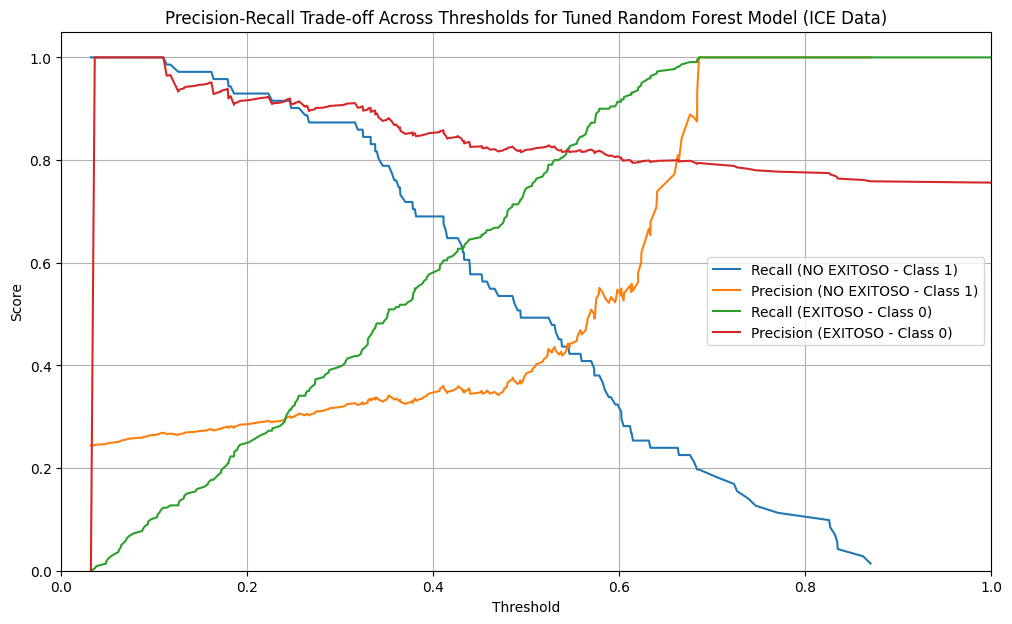

In [55]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities for the positive class (1: 'NO EXITOSO') from the best Random Forest model for ICE data
y_pred_proba_rf_ice = best_rf_model_ice.predict_proba(X_test_ice)[:, 1]

# Calculate precision, recall, and thresholds for the positive class (NO EXITOSO)
precisions_rf_ice, recalls_rf_ice, thresholds_rf_ice = precision_recall_curve(y_test_ice, y_pred_proba_rf_ice, pos_label=1)

# To analyze the trade-off, we can also calculate metrics for the negative class (EXITOSO)
thresholds_extended_rf_ice = np.append(thresholds_rf_ice, 1.0) # Add 1.0 to thresholds to include all predictions

precision_0_rf_ice = []
recall_0_rf_ice = []

for t in thresholds_extended_rf_ice:
    y_pred_at_t_rf_ice = (y_pred_proba_rf_ice >= t).astype(int)

    true_negatives_rf_ice = np.sum((y_test_ice == 0) & (y_pred_at_t_rf_ice == 0))
    false_positives_rf_ice = np.sum((y_test_ice == 0) & (y_pred_at_t_rf_ice == 1))
    false_negatives_rf_ice = np.sum((y_test_ice == 1) & (y_pred_at_t_rf_ice == 0))
    true_positives_rf_ice = np.sum((y_test_ice == 1) & (y_pred_at_t_rf_ice == 1))

    precision_class_0_rf_ice = true_negatives_rf_ice / (true_negatives_rf_ice + false_negatives_rf_ice) if (true_negatives_rf_ice + false_negatives_rf_ice) > 0 else 0
    recall_class_0_rf_ice = true_negatives_rf_ice / (true_negatives_rf_ice + false_positives_rf_ice) if (true_negatives_rf_ice + false_positives_rf_ice) > 0 else 0

    precision_0_rf_ice.append(precision_class_0_rf_ice)
    recall_0_rf_ice.append(recall_class_0_rf_ice)

# Plotting
plt.figure(figsize=(12, 7))
plt.plot(thresholds_rf_ice, recalls_rf_ice[:-1], label='Recall (NO EXITOSO - Class 1)')
plt.plot(thresholds_rf_ice, precisions_rf_ice[:-1], label='Precision (NO EXITOSO - Class 1)')
plt.plot(thresholds_extended_rf_ice, np.array(recall_0_rf_ice), label='Recall (EXITOSO - Class 0)')
plt.plot(thresholds_extended_rf_ice, np.array(precision_0_rf_ice), label='Precision (EXITOSO - Class 0)')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off Across Thresholds for Tuned Random Forest Model (ICE Data)')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

### Threshold Optimization for Random Forest using F1-score (ICE Data)

Optimal F1-score threshold for Random Forest model (ICE Data): 0.3327


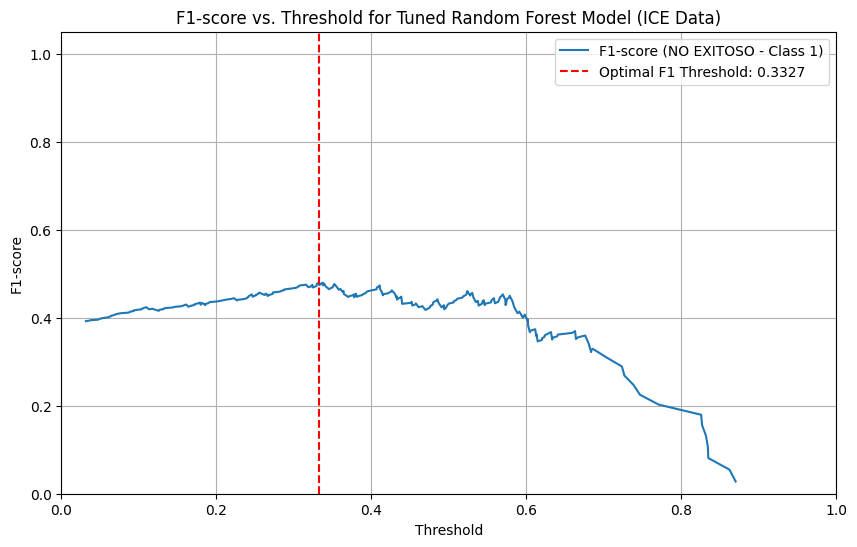

In [56]:
from sklearn.metrics import f1_score

# Calculate F1-scores for each threshold
f1_scores_rf_ice = 2 * (precisions_rf_ice * recalls_rf_ice) / (precisions_rf_ice + recalls_rf_ice)

# Find the optimal threshold (where F1-score is maximized)
optimal_threshold_idx_rf_ice = np.argmax(f1_scores_rf_ice)
optimal_f1_threshold_rf_ice = thresholds_rf_ice[optimal_threshold_idx_rf_ice]

print(f"Optimal F1-score threshold for Random Forest model (ICE Data): {optimal_f1_threshold_rf_ice:.4f}")

# Plot F1-score vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds_rf_ice, f1_scores_rf_ice[:-1], label='F1-score (NO EXITOSO - Class 1)')
plt.axvline(x=optimal_f1_threshold_rf_ice, color='r', linestyle='--', label=f'Optimal F1 Threshold: {optimal_f1_threshold_rf_ice:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs. Threshold for Tuned Random Forest Model (ICE Data)')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

In [57]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, f1_score, precision_score, recall_score

# Evaluate the best Random Forest model on the test set with the optimal F1-score threshold
y_test_pred_at_optimal_f1_threshold_rf_ice = (y_pred_proba_rf_ice >= optimal_f1_threshold_rf_ice).astype(int)

roc_auc_ice_rf = roc_auc_score(y_test_ice, y_pred_proba_rf_ice)
report_ice_rf = classification_report(y_test_ice, y_test_pred_at_optimal_f1_threshold_rf_ice, output_dict=True)
recall_1_ice_rf = report_ice_rf['1']['recall']
precision_0_ice_rf = report_ice_rf['0']['precision']
f1_1_ice_rf = report_ice_rf['1']['f1-score']

print(f"--- Tuned Random Forest Model Evaluation (ICE Data) - TEST SET with Optimal F1 Threshold = {optimal_f1_threshold_rf_ice:.4f} ---")
print(f"ROC AUC Score: {roc_auc_ice_rf:.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ice, y_test_pred_at_optimal_f1_threshold_rf_ice):.4f}")
print(f"Recall (Class 1 - NO EXITOSO): {recall_1_ice_rf:.4f}")
print(f"Precision (Class 0 - EXITOSO): {precision_0_ice_rf:.4f}")
print(f"F1-score (Class 1 - NO EXITOSO): {f1_1_ice_rf:.4f}")
print("\nClassification Report:\n", classification_report(y_test_ice, y_test_pred_at_optimal_f1_threshold_rf_ice))

--- Tuned Random Forest Model Evaluation (ICE Data) - TEST SET with Optimal F1 Threshold = 0.3327 ---
ROC AUC Score: 0.7099
Accuracy Score: 0.5533
Recall (Class 1 - NO EXITOSO): 0.8451
Precision (Class 0 - EXITOSO): 0.9018
F1-score (Class 1 - NO EXITOSO): 0.4800

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.46      0.61       220
           1       0.34      0.85      0.48        71

    accuracy                           0.55       291
   macro avg       0.62      0.65      0.54       291
weighted avg       0.76      0.55      0.58       291



### Threshold Optimization for Random Forest: Precision-Recall Trade-off (EV Data)

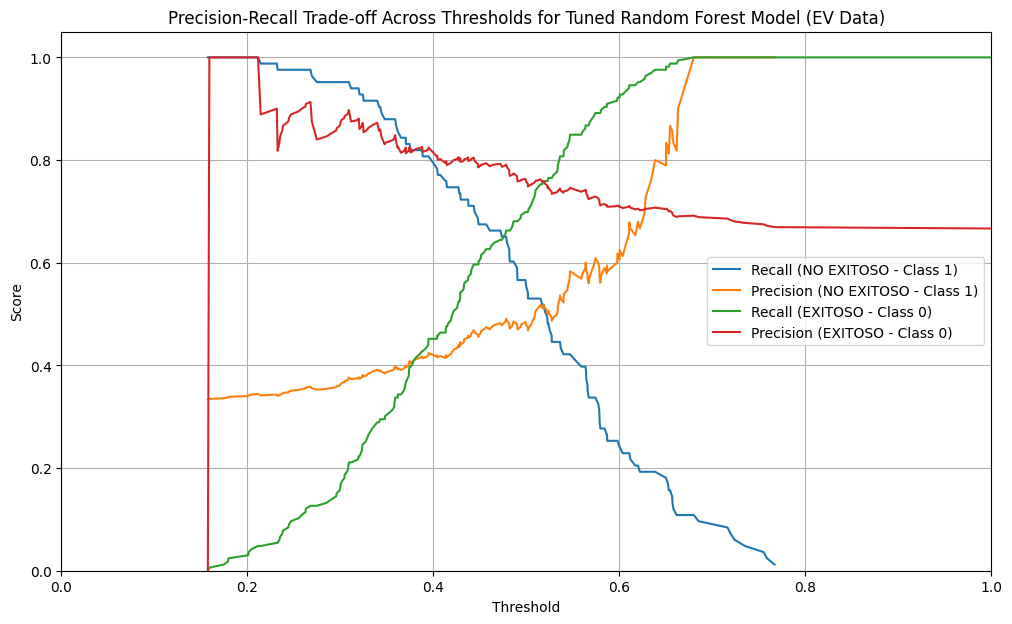

In [58]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities for the positive class (1: 'NO EXITOSO') from the best Random Forest model for EV data (v5)
y_pred_proba_rf_ev = best_rf_model_ev_v5.predict_proba(X_test_ev)[:, 1]

# Calculate precision, recall, and thresholds for the positive class (NO EXITOSO)
precisions_rf_ev, recalls_rf_ev, thresholds_rf_ev = precision_recall_curve(y_test_ev, y_pred_proba_rf_ev, pos_label=1)

# To analyze the trade-off, we can also calculate metrics for the negative class (EXITOSO)
thresholds_extended_rf_ev = np.append(thresholds_rf_ev, 1.0) # Add 1.0 to thresholds to include all predictions

precision_0_rf_ev = []
recall_0_rf_ev = []

for t in thresholds_extended_rf_ev:
    y_pred_at_t_rf_ev = (y_pred_proba_rf_ev >= t).astype(int)

    true_negatives_rf_ev = np.sum((y_test_ev == 0) & (y_pred_at_t_rf_ev == 0))
    false_positives_rf_ev = np.sum((y_test_ev == 0) & (y_pred_at_t_rf_ev == 1))
    false_negatives_rf_ev = np.sum((y_test_ev == 1) & (y_pred_at_t_rf_ev == 0))
    true_positives_rf_ev = np.sum((y_test_ev == 1) & (y_pred_at_t_rf_ev == 1))

    precision_class_0_rf_ev = true_negatives_rf_ev / (true_negatives_rf_ev + false_negatives_rf_ev) if (true_negatives_rf_ev + false_negatives_rf_ev) > 0 else 0
    recall_class_0_rf_ev = true_negatives_rf_ev / (true_negatives_rf_ev + false_positives_rf_ev) if (true_negatives_rf_ev + false_positives_rf_ev) > 0 else 0

    precision_0_rf_ev.append(precision_class_0_rf_ev)
    recall_0_rf_ev.append(recall_class_0_rf_ev)

# Plotting
plt.figure(figsize=(12, 7))
plt.plot(thresholds_rf_ev, recalls_rf_ev[:-1], label='Recall (NO EXITOSO - Class 1)')
plt.plot(thresholds_rf_ev, precisions_rf_ev[:-1], label='Precision (NO EXITOSO - Class 1)')
plt.plot(thresholds_extended_rf_ev, np.array(recall_0_rf_ev), label='Recall (EXITOSO - Class 0)')
plt.plot(thresholds_extended_rf_ev, np.array(precision_0_rf_ev), label='Precision (EXITOSO - Class 0)')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off Across Thresholds for Tuned Random Forest Model (EV Data)')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

### Threshold Optimization for Random Forest using F1-score (EV Data)

Optimal F1-score threshold for Random Forest model (EV Data): 0.4434


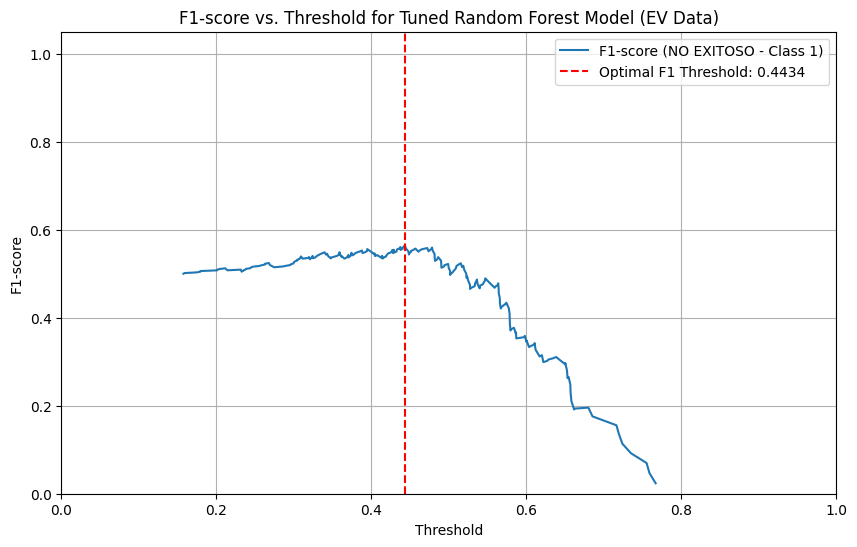

In [59]:
from sklearn.metrics import f1_score

# Calculate F1-scores for each threshold
f1_scores_rf_ev = 2 * (precisions_rf_ev * recalls_rf_ev) / (precisions_rf_ev + recalls_rf_ev)

# Find the optimal threshold (where F1-score is maximized)
optimal_threshold_idx_rf_ev = np.argmax(f1_scores_rf_ev)
optimal_f1_threshold_rf_ev = thresholds_rf_ev[optimal_threshold_idx_rf_ev]

print(f"Optimal F1-score threshold for Random Forest model (EV Data): {optimal_f1_threshold_rf_ev:.4f}")

# Plot F1-score vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds_rf_ev, f1_scores_rf_ev[:-1], label='F1-score (NO EXITOSO - Class 1)')
plt.axvline(x=optimal_f1_threshold_rf_ev, color='r', linestyle='--', label=f'Optimal F1 Threshold: {optimal_f1_threshold_rf_ev:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs. Threshold for Tuned Random Forest Model (EV Data)')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

In [60]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, f1_score, precision_score, recall_score

# Evaluate the best Random Forest model on the test set with the optimal F1-score threshold
y_test_pred_at_optimal_f1_threshold_rf_ev = (y_pred_proba_rf_ev >= optimal_f1_threshold_rf_ev).astype(int)

roc_auc_ev_rf = roc_auc_score(y_test_ev, y_pred_proba_rf_ev)
report_ev_rf = classification_report(y_test_ev, y_test_pred_at_optimal_f1_threshold_rf_ev, output_dict=True)
recall_1_ev_rf = report_ev_rf['1']['recall']
precision_0_ev_rf = report_ev_rf['0']['precision']
f1_1_ev_rf = report_ev_rf['1']['f1-score']

print(f"--- Tuned Random Forest Model Evaluation (EV Data) - TEST SET with Optimal F1 Threshold = {optimal_f1_threshold_rf_ev:.4f} ---")
print(f"ROC AUC Score: {roc_auc_ev_rf:.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ev, y_test_pred_at_optimal_f1_threshold_rf_ev):.4f}")
print(f"Recall (Class 1 - NO EXITOSO): {recall_1_ev_rf:.4f}")
print(f"Precision (Class 0 - EXITOSO): {precision_0_ev_rf:.4f}")
print(f"F1-score (Class 1 - NO EXITOSO): {f1_1_ev_rf:.4f}")
print("\nClassification Report:\n", classification_report(y_test_ev, y_test_pred_at_optimal_f1_threshold_rf_ev))

--- Tuned Random Forest Model Evaluation (EV Data) - TEST SET with Optimal F1 Threshold = 0.4434 ---
ROC AUC Score: 0.6957
Accuracy Score: 0.6345
Recall (Class 1 - NO EXITOSO): 0.7108
Precision (Class 0 - EXITOSO): 0.8049
F1-score (Class 1 - NO EXITOSO): 0.5646

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.60      0.69       166
           1       0.47      0.71      0.56        83

    accuracy                           0.63       249
   macro avg       0.64      0.65      0.62       249
weighted avg       0.69      0.63      0.64       249



In [61]:
# Evaluate the best Random Forest model on the test set with the optimal F1-score threshold
y_test_pred_at_optimal_f1_threshold_rf_ev = (y_pred_proba_rf_ev >= optimal_f1_threshold_rf_ev).astype(int)

roc_auc_ev_rf = roc_auc_score(y_test_ev, y_pred_proba_rf_ev)
report_ev_rf = classification_report(y_test_ev, y_test_pred_at_optimal_f1_threshold_rf_ev, output_dict=True)
recall_1_ev_rf = report_ev_rf['1']['recall']
precision_0_ev_rf = report_ev_rf['0']['precision']
f1_1_ev_rf = report_ev_rf['1']['f1-score']

print(f"--- Tuned Random Forest Model Evaluation (EV Data) - TEST SET with Optimal F1 Threshold = {optimal_f1_threshold_rf_ev:.4f} ---")
print(f"ROC AUC Score: {roc_auc_ev_rf:.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ev, y_test_pred_at_optimal_f1_threshold_rf_ev):.4f}")
print(f"Recall (Class 1 - NO EXITOSO): {recall_1_ev_rf:.4f}")
print(f"Precision (Class 0 - EXITOSO): {precision_0_ev_rf:.4f}")
print(f"F1-score (Class 1 - NO EXITOSO): {f1_1_ev_rf:.4f}")
print("\nClassification Report:\n", classification_report(y_test_ev, y_test_pred_at_optimal_f1_threshold_rf_ev))

--- Tuned Random Forest Model Evaluation (EV Data) - TEST SET with Optimal F1 Threshold = 0.4434 ---
ROC AUC Score: 0.6957
Accuracy Score: 0.6345
Recall (Class 1 - NO EXITOSO): 0.7108
Precision (Class 0 - EXITOSO): 0.8049
F1-score (Class 1 - NO EXITOSO): 0.5646

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.60      0.69       166
           1       0.47      0.71      0.56        83

    accuracy                           0.63       249
   macro avg       0.64      0.65      0.62       249
weighted avg       0.69      0.63      0.64       249



In [62]:
import pandas as pd

# Prepare the data for the final updated table with all metrics
data_final_summary = {
    'Model': ['Lasso', 'Lasso', 'LightGBM', 'LightGBM', 'Random Forest', 'Random Forest'],
    'TM': ['EV', 'ICE', 'EV', 'ICE', 'EV', 'ICE'],
    'Optimal F1-score Threshold': [
        optimal_f1_threshold_lasso,
        optimal_f1_threshold_lasso_ice,
        optimal_f1_threshold_lgbm,
        optimal_f1_threshold_lgbm_ice,
        optimal_f1_threshold_rf_ev,
        optimal_f1_threshold_rf_ice
    ],
    'ROC AUC Score': [
        roc_auc_ev_lasso,
        roc_auc_ice_lasso,
        roc_auc_ev_lgbm,
        roc_auc_ice_lgbm,
        roc_auc_ev_rf,
        roc_auc_ice_rf
    ],
    'Recall (Class 1 - NO EXITOSO)': [
        recall_1_ev_lasso,
        recall_1_ice_lasso,
        recall_1_ev_lgbm,
        recall_1_ice_lgbm,
        recall_1_ev_rf,
        recall_1_ice_rf
    ],
    'Precision (Class 0 - EXITOSO)': [
        precision_0_ev_lasso,
        precision_0_ice_lasso,
        precision_0_ev_lgbm,
        precision_0_ice_lgbm,
        precision_0_ev_rf,
        precision_0_ice_rf
    ],
    'F1-score (Class 1 - NO EXITOSO)': [
        f1_1_ev_lasso,
        f1_1_ice_lasso,
        f1_1_ev_lgbm,
        f1_1_ice_lgbm,
        f1_1_ev_rf,
        f1_1_ice_rf
    ]
}

metrics_summary_df_final = pd.DataFrame(data_final_summary)

print("Tabla resumen completa de métricas por modelo y tipo de motor (TM) (Actualizado con Random Forest EV):")
display(metrics_summary_df_final)

NameError: name 'optimal_f1_threshold_lgbm_ice' is not defined

In [63]:
# Re-execute cell to define f1_1_ev_rf
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, f1_score, precision_score, recall_score

# Evaluate the best Random Forest model on the test set with the optimal F1-score threshold
y_test_pred_at_optimal_f1_threshold_rf_ev = (y_pred_proba_rf_ev >= optimal_f1_threshold_rf_ev).astype(int)

roc_auc_ev_rf = roc_auc_score(y_test_ev, y_pred_proba_rf_ev)
report_ev_rf = classification_report(y_test_ev, y_test_pred_at_optimal_f1_threshold_rf_ev, output_dict=True)
recall_1_ev_rf = report_ev_rf['1']['recall']
precision_0_ev_rf = report_ev_rf['0']['precision']
f1_1_ev_rf = report_ev_rf['1']['f1-score']

print(f"--- Tuned Random Forest Model Evaluation (EV Data) - TEST SET with Optimal F1 Threshold = {optimal_f1_threshold_rf_ev:.4f} ---")
print(f"ROC AUC Score: {roc_auc_ev_rf:.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ev, y_test_pred_at_optimal_f1_threshold_rf_ev):.4f}")
print(f"Recall (Class 1 - NO EXITOSO): {recall_1_ev_rf:.4f}")
print(f"Precision (Class 0 - EXITOSO): {precision_0_ev_rf:.4f}")
print(f"F1-score (Class 1 - NO EXITOSO): {f1_1_ev_rf:.4f}")
print("\nClassification Report:\n", classification_report(y_test_ev, y_test_pred_at_optimal_f1_threshold_rf_ev))

--- Tuned Random Forest Model Evaluation (EV Data) - TEST SET with Optimal F1 Threshold = 0.4434 ---
ROC AUC Score: 0.6957
Accuracy Score: 0.6345
Recall (Class 1 - NO EXITOSO): 0.7108
Precision (Class 0 - EXITOSO): 0.8049
F1-score (Class 1 - NO EXITOSO): 0.5646

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.60      0.69       166
           1       0.47      0.71      0.56        83

    accuracy                           0.63       249
   macro avg       0.64      0.65      0.62       249
weighted avg       0.69      0.63      0.64       249



In [64]:
# Re-execute cell to generate the final summary table
import pandas as pd

# Prepare the data for the final updated table with all metrics
data_final_summary = {
    'Model': ['Lasso', 'Lasso', 'LightGBM', 'LightGBM', 'Random Forest', 'Random Forest'],
    'TM': ['EV', 'ICE', 'EV', 'ICE', 'EV', 'ICE'],
    'Optimal F1-score Threshold': [
        optimal_f1_threshold_lasso,
        optimal_f1_threshold_lasso_ice,
        optimal_f1_threshold_lgbm,
        optimal_f1_threshold_lgbm_ice,
        optimal_f1_threshold_rf_ev,
        optimal_f1_threshold_rf_ice
    ],
    'ROC AUC Score': [
        roc_auc_ev_lasso,
        roc_auc_ice_lasso,
        roc_auc_ev_lgbm,
        roc_auc_ice_lgbm,
        roc_auc_ev_rf,
        roc_auc_ice_rf
    ],
    'Recall (Class 1 - NO EXITOSO)': [
        recall_1_ev_lasso,
        recall_1_ice_lasso,
        recall_1_ev_lgbm,
        recall_1_ice_lgbm,
        recall_1_ev_rf,
        recall_1_ice_rf
    ],
    'Precision (Class 0 - EXITOSO)': [
        precision_0_ev_lasso,
        precision_0_ice_lasso,
        precision_0_ev_lgbm,
        precision_0_ice_lgbm,
        precision_0_ev_rf,
        precision_0_ice_rf
    ],
    'F1-score (Class 1 - NO EXITOSO)': [
        f1_1_ev_lasso,
        f1_1_ice_lasso,
        f1_1_ev_lgbm,
        f1_1_ice_lgbm,
        f1_1_ev_rf,
        f1_1_ice_rf
    ]
}

metrics_summary_df_final = pd.DataFrame(data_final_summary)

print("Tabla resumen completa de métricas por modelo y tipo de motor (TM) (Actualizado con Random Forest EV):")
display(metrics_summary_df_final)

NameError: name 'optimal_f1_threshold_lgbm_ice' is not defined

### Final Updated Summary Table of All Model Metrics

In [72]:
import pandas as pd

# Prepare the data for the final updated table with all metrics
data_final_summary = {
    'Model': ['Lasso', 'Lasso', 'LightGBM', 'LightGBM', 'Random Forest', 'Random Forest'],
    'TM': ['EV', 'ICE', 'EV', 'ICE', 'EV', 'ICE'],
    'Optimal F1-score Threshold': [
        optimal_f1_threshold_lasso,
        optimal_f1_threshold_lasso_ice,
        optimal_f1_threshold_lgbm,
        optimal_f1_threshold_lgbm_ice,
        optimal_f1_threshold_rf_ev,
        optimal_f1_threshold_rf_ice
    ],
    'ROC AUC Score': [
        roc_auc_ev_lasso,
        roc_auc_ice_lasso,
        roc_auc_ev_lgbm,
        roc_auc_ice_lgbm,
        roc_auc_ev_rf,
        roc_auc_ice_rf
    ],
    'Recall (Class 1 - NO EXITOSO)': [
        recall_1_ev_lasso,
        recall_1_ice_lasso,
        recall_1_ev_lgbm,
        recall_1_ice_lgbm,
        recall_1_ev_rf,
        recall_1_ice_rf
    ],
    'Precision (Class 0 - EXITOSO)': [
        precision_0_ev_lasso,
        precision_0_ice_lasso,
        precision_0_ev_lgbm,
        precision_0_ice_lgbm,
        precision_0_ev_rf,
        precision_0_ice_rf
    ],
    'F1-score (Class 1 - NO EXITOSO)': [
        f1_1_ev_lasso,
        f1_1_ice_lasso,
        f1_1_ev_lgbm,
        f1_1_ice_lgbm,
        f1_1_ev_rf,
        f1_1_ice_rf
    ]
}

metrics_summary_df_final = pd.DataFrame(data_final_summary)

print("Tabla resumen completa de métricas por modelo y tipo de motor (TM) (Actualizado con Random Forest EV):")
display(metrics_summary_df_final)

Tabla resumen completa de métricas por modelo y tipo de motor (TM) (Actualizado con Random Forest EV):


,Model,TM,Optimal F1-score Threshold,ROC AUC Score,Recall (Class 1 - NO EXITOSO),Precision (Class 0 - EXITOSO),F1-score (Class 1 - NO EXITOSO)
0,Lasso,EV,0.578531,0.641748,0.927711,0.900000,0.566176
1,Lasso,ICE,0.630324,0.680666,0.605634,0.845304,0.475138
2,LightGBM,EV,0.566049,0.706307,0.638554,0.794521,0.569892
3,LightGBM,ICE,0.576909,0.701889,0.408451,0.824268,0.471545
4,Random Forest,EV,0.443431,0.695747,0.710843,0.804878,0.564593
5,Random Forest,ICE,0.332657,0.709923,0.845070,0.901786,0.480000


### Updated Summary Table of All Model Metrics

In [71]:
import pandas as pd

# Prepare the data for the updated table with all metrics
data_final_updated = {
    'Model': ['Lasso', 'Lasso', 'LightGBM', 'LightGBM', 'Random Forest'],
    'TM': ['EV', 'ICE', 'EV', 'ICE', 'ICE'],
    'Optimal F1-score Threshold': [
        optimal_f1_threshold_lasso,
        optimal_f1_threshold_lasso_ice,
        optimal_f1_threshold_lgbm,
        optimal_f1_threshold_lgbm_ice,
        optimal_f1_threshold_rf_ice
    ],
    'ROC AUC Score': [
        roc_auc_ev_lasso,
        roc_auc_ice_lasso,
        roc_auc_ev_lgbm,
        roc_auc_ice_lgbm,
        roc_auc_ice_rf
    ],
    'Recall (Class 1 - NO EXITOSO)': [
        recall_1_ev_lasso,
        recall_1_ice_lasso,
        recall_1_ev_lgbm,
        recall_1_ice_lgbm,
        recall_1_ice_rf
    ],
    'Precision (Class 0 - EXITOSO)': [
        precision_0_ev_lasso,
        precision_0_ice_lasso,
        precision_0_ev_lgbm,
        precision_0_ice_lgbm,
        precision_0_ice_rf
    ],
    'F1-score (Class 1 - NO EXITOSO)': [
        f1_1_ev_lasso,
        f1_1_ice_lasso,
        f1_1_ev_lgbm,
        f1_1_ice_lgbm,
        f1_1_ice_rf
    ]
}

metrics_summary_df_updated = pd.DataFrame(data_final_updated)

print("Tabla resumen completa de métricas por modelo y tipo de motor (TM) (Actualizado):")
display(metrics_summary_df_updated)

Tabla resumen completa de métricas por modelo y tipo de motor (TM) (Actualizado):


,Model,TM,Optimal F1-score Threshold,ROC AUC Score,Recall (Class 1 - NO EXITOSO),Precision (Class 0 - EXITOSO),F1-score (Class 1 - NO EXITOSO)
0,Lasso,EV,0.578531,0.641748,0.927711,0.900000,0.566176
1,Lasso,ICE,0.630324,0.680666,0.605634,0.845304,0.475138
2,LightGBM,EV,0.566049,0.706307,0.638554,0.794521,0.569892
3,LightGBM,ICE,0.576909,0.701889,0.408451,0.824268,0.471545
4,Random Forest,ICE,0.332657,0.709923,0.845070,0.901786,0.480000


### Threshold Optimization for LightGBM: Precision-Recall Trade-off (ICE Data)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


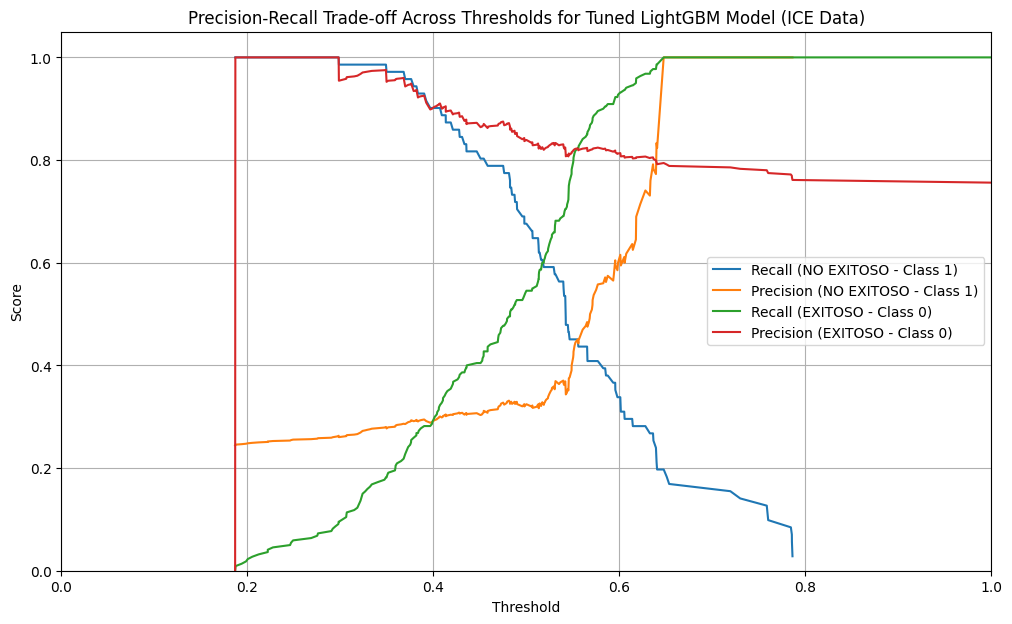

In [65]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities for the positive class (1: 'NO EXITOSO') from the best LightGBM model for ICE data
y_pred_proba_lgbm_ice = best_lgbm_model_ice.predict_proba(X_test_ice)[:, 1]

# Calculate precision, recall, and thresholds for the positive class (NO EXITOSO)
precisions_lgbm_ice, recalls_lgbm_ice, thresholds_lgbm_ice = precision_recall_curve(y_test_ice, y_pred_proba_lgbm_ice, pos_label=1)

# To analyze the trade-off, we can also calculate metrics for the negative class (EXITOSO)
thresholds_extended_lgbm_ice = np.append(thresholds_lgbm_ice, 1.0) # Add 1.0 to thresholds to include all predictions

precision_0_lgbm_ice = []
recall_0_lgbm_ice = []

for t in thresholds_extended_lgbm_ice:
    y_pred_at_t_lgbm_ice = (y_pred_proba_lgbm_ice >= t).astype(int)

    true_negatives_lgbm_ice = np.sum((y_test_ice == 0) & (y_pred_at_t_lgbm_ice == 0))
    false_positives_lgbm_ice = np.sum((y_test_ice == 0) & (y_pred_at_t_lgbm_ice == 1))
    false_negatives_lgbm_ice = np.sum((y_test_ice == 1) & (y_pred_at_t_lgbm_ice == 0))
    true_positives_lgbm_ice = np.sum((y_test_ice == 1) & (y_pred_at_t_lgbm_ice == 1))

    precision_class_0_lgbm_ice = true_negatives_lgbm_ice / (true_negatives_lgbm_ice + false_negatives_lgbm_ice) if (true_negatives_lgbm_ice + false_negatives_lgbm_ice) > 0 else 0
    recall_class_0_lgbm_ice = true_negatives_lgbm_ice / (true_negatives_lgbm_ice + false_positives_lgbm_ice) if (true_negatives_lgbm_ice + false_positives_lgbm_ice) > 0 else 0

    precision_0_lgbm_ice.append(precision_class_0_lgbm_ice)
    recall_0_lgbm_ice.append(recall_class_0_lgbm_ice)

# Plotting
plt.figure(figsize=(12, 7))
plt.plot(thresholds_lgbm_ice, recalls_lgbm_ice[:-1], label='Recall (NO EXITOSO - Class 1)')
plt.plot(thresholds_lgbm_ice, precisions_lgbm_ice[:-1], label='Precision (NO EXITOSO - Class 1)')
plt.plot(thresholds_extended_lgbm_ice, np.array(recall_0_lgbm_ice), label='Recall (EXITOSO - Class 0)')
plt.plot(thresholds_extended_lgbm_ice, np.array(precision_0_lgbm_ice), label='Precision (EXITOSO - Class 0)')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off Across Thresholds for Tuned LightGBM Model (ICE Data)')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

### Threshold Optimization for LightGBM using F1-score (ICE Data)

Optimal F1-score threshold for LightGBM model (ICE Data): 0.5769


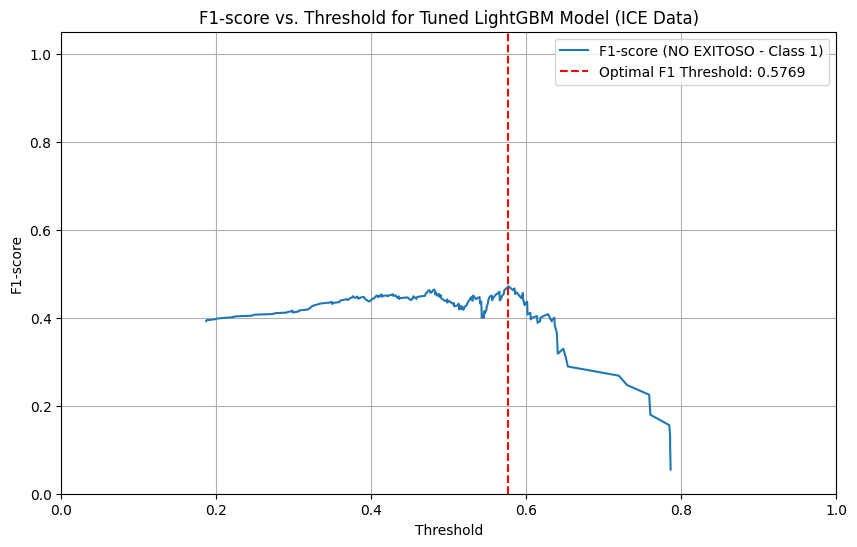

In [66]:
from sklearn.metrics import f1_score

# Calculate F1-scores for each threshold
f1_scores_lgbm_ice = 2 * (precisions_lgbm_ice * recalls_lgbm_ice) / (precisions_lgbm_ice + recalls_lgbm_ice)

# Find the optimal threshold (where F1-score is maximized)
optimal_threshold_idx_lgbm_ice = np.argmax(f1_scores_lgbm_ice)
optimal_f1_threshold_lgbm_ice = thresholds_lgbm_ice[optimal_threshold_idx_lgbm_ice]

print(f"Optimal F1-score threshold for LightGBM model (ICE Data): {optimal_f1_threshold_lgbm_ice:.4f}")

# Plot F1-score vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds_lgbm_ice, f1_scores_lgbm_ice[:-1], label='F1-score (NO EXITOSO - Class 1)')
plt.axvline(x=optimal_f1_threshold_lgbm_ice, color='r', linestyle='--', label=f'Optimal F1 Threshold: {optimal_f1_threshold_lgbm_ice:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs. Threshold for Tuned LightGBM Model (ICE Data)')
plt.legend()
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

In [67]:
# Evaluate the best LightGBM model on the test set with the optimal F1-score threshold
y_test_pred_at_optimal_f1_threshold_lgbm_ice = (y_pred_proba_lgbm_ice >= optimal_f1_threshold_lgbm_ice).astype(int)

print(f"--- Tuned LightGBM Model Evaluation (ICE Data) - TEST SET with Optimal F1 Threshold = {optimal_f1_threshold_lgbm_ice:.4f} ---")
print(f"ROC AUC Score: {roc_auc_score(y_test_ice, y_pred_proba_lgbm_ice):.4f}")
print(f"Accuracy Score: {accuracy_score(y_test_ice, y_test_pred_at_optimal_f1_threshold_lgbm_ice):.4f}")
print("\nClassification Report:\n", classification_report(y_test_ice, y_test_pred_at_optimal_f1_threshold_lgbm_ice))

print("\n" + "="*70 + "\n")

# Evaluate the best LightGBM model on the TRAINING set with the optimal F1-score threshold
y_train_pred_at_optimal_f1_threshold_lgbm_ice = (y_train_pred_proba_best_lgbm_ice >= optimal_f1_threshold_lgbm_ice).astype(int)

print(f"--- Tuned LightGBM Model Evaluation (ICE Data) - TRAINING SET with Optimal F1 Threshold = {optimal_f1_threshold_lgbm_ice:.4f} ---")
print(f"ROC AUC Score: {roc_auc_score(y_train_ice, y_train_pred_proba_best_lgbm_ice):.4f}")
print(f"Accuracy Score: {accuracy_score(y_train_ice, y_train_pred_at_optimal_f1_threshold_lgbm_ice):.4f}")
print("\nClassification Report:\n", classification_report(y_train_ice, y_train_pred_at_optimal_f1_threshold_lgbm_ice))

--- Tuned LightGBM Model Evaluation (ICE Data) - TEST SET with Optimal F1 Threshold = 0.5769 ---
ROC AUC Score: 0.7019
Accuracy Score: 0.7766

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86       220
           1       0.56      0.41      0.47        71

    accuracy                           0.78       291
   macro avg       0.69      0.65      0.66       291
weighted avg       0.76      0.78      0.76       291



--- Tuned LightGBM Model Evaluation (ICE Data) - TRAINING SET with Optimal F1 Threshold = 0.5769 ---
ROC AUC Score: 0.8127
Accuracy Score: 0.7850

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86       878
           1       0.59      0.40      0.48       285

    accuracy                           0.79      1163
   macro avg       0.71      0.66      0.67      1163
weighted avg       0.77      0.79      0.77      1163



### Updated Summary Table of Optimal F1-score Thresholds

In [68]:
import pandas as pd

# Prepare the data for the updated table
data_updated = {
    'Model': ['Lasso', 'Lasso', 'LightGBM', 'LightGBM'],
    'TM': ['EV', 'ICE', 'EV', 'ICE'],
    'Optimal F1-score Threshold': [
        optimal_f1_threshold_lasso,
        optimal_f1_threshold_lasso_ice,
        optimal_f1_threshold_lgbm,
        optimal_f1_threshold_lgbm_ice
    ]
}

thresholds_df_updated = pd.DataFrame(data_updated)

print("Umbrales óptimos de F1-score por modelo y tipo de motor (TM) (Actualizado):")
display(thresholds_df_updated)

Umbrales óptimos de F1-score por modelo y tipo de motor (TM) (Actualizado):


,Model,TM,Optimal F1-score Threshold
0,Lasso,EV,0.578531
1,Lasso,ICE,0.630324
2,LightGBM,EV,0.566049
3,LightGBM,ICE,0.576909


In [69]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, f1_score, precision_score, recall_score
import numpy as np

# --- Calculate Metrics for Lasso EV ---
y_pred_proba_lasso_ev_test = best_lasso_model_ev.predict_proba(X_test_ev)[:, 1]
y_pred_at_optimal_f1_threshold_lasso_eval = (y_pred_proba_lasso_ev_test >= optimal_f1_threshold_lasso).astype(int)

roc_auc_ev_lasso = roc_auc_score(y_test_ev, y_pred_proba_lasso_ev_test)
report_ev_lasso = classification_report(y_test_ev, y_pred_at_optimal_f1_threshold_lasso_eval, output_dict=True)
recall_1_ev_lasso = report_ev_lasso['1']['recall']
precision_0_ev_lasso = report_ev_lasso['0']['precision']
f1_1_ev_lasso = report_ev_lasso['1']['f1-score']

# --- Calculate Metrics for LightGBM EV ---
y_pred_proba_lgbm_ev_test = best_lgbm_model_ev.predict_proba(X_test_ev)[:, 1]
y_pred_at_optimal_f1_threshold_lgbm_eval = (y_pred_proba_lgbm_ev_test >= optimal_f1_threshold_lgbm).astype(int)

roc_auc_ev_lgbm = roc_auc_score(y_test_ev, y_pred_proba_lgbm_ev_test)
report_ev_lgbm = classification_report(y_test_ev, y_pred_at_optimal_f1_threshold_lgbm_eval, output_dict=True)
recall_1_ev_lgbm = report_ev_lgbm['1']['recall']
precision_0_ev_lgbm = report_ev_lgbm['0']['precision']
f1_1_ev_lgbm = report_ev_lgbm['1']['f1-score']

# --- Calculate Metrics for LightGBM ICE ---
y_pred_proba_lgbm_ice_test = best_lgbm_model_ice.predict_proba(X_test_ice)[:, 1]
y_pred_at_optimal_f1_threshold_lgbm_ice_eval = (y_pred_proba_lgbm_ice_test >= optimal_f1_threshold_lgbm_ice).astype(int)

roc_auc_ice_lgbm = roc_auc_score(y_test_ice, y_pred_proba_lgbm_ice_test)
report_ice_lgbm = classification_report(y_test_ice, y_pred_at_optimal_f1_threshold_lgbm_ice_eval, output_dict=True)
recall_1_ice_lgbm = report_ice_lgbm['1']['recall']
precision_0_ice_lgbm = report_ice_lgbm['0']['precision']
f1_1_ice_lgbm = report_ice_lgbm['1']['f1-score']

print("Metrics calculated for all models.")

Metrics calculated for all models.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [70]:
# Prepare the data for the updated table with all metrics
data_final = {
    'Model': ['Lasso', 'Lasso', 'LightGBM', 'LightGBM'],
    'TM': ['EV', 'ICE', 'EV', 'ICE'],
    'Optimal F1-score Threshold': [
        optimal_f1_threshold_lasso,
        optimal_f1_threshold_lasso_ice,
        optimal_f1_threshold_lgbm,
        optimal_f1_threshold_lgbm_ice
    ],
    'ROC AUC Score': [
        roc_auc_ev_lasso,
        roc_auc_ice_lasso,
        roc_auc_ev_lgbm,
        roc_auc_ice_lgbm
    ],
    'Recall (Class 1 - NO EXITOSO)': [
        recall_1_ev_lasso,
        recall_1_ice_lasso,
        recall_1_ev_lgbm,
        recall_1_ice_lgbm
    ],
    'Precision (Class 0 - EXITOSO)': [
        precision_0_ev_lasso,
        precision_0_ice_lasso,
        precision_0_ev_lgbm,
        precision_0_ice_lgbm
    ],
    'F1-score (Class 1 - NO EXITOSO)': [
        f1_1_ev_lasso,
        f1_1_ice_lasso,
        f1_1_ev_lgbm,
        f1_1_ice_lgbm
    ]
}

metrics_summary_df = pd.DataFrame(data_final)

print("Tabla resumen completa de métricas por modelo y tipo de motor (TM):")
display(metrics_summary_df)

Tabla resumen completa de métricas por modelo y tipo de motor (TM):


,Model,TM,Optimal F1-score Threshold,ROC AUC Score,Recall (Class 1 - NO EXITOSO),Precision (Class 0 - EXITOSO),F1-score (Class 1 - NO EXITOSO)
0,Lasso,EV,0.578531,0.641748,0.927711,0.900000,0.566176
1,Lasso,ICE,0.630324,0.680666,0.605634,0.845304,0.475138
2,LightGBM,EV,0.566049,0.706307,0.638554,0.794521,0.569892
3,LightGBM,ICE,0.576909,0.701889,0.408451,0.824268,0.471545


In [73]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, f1_score, precision_score, recall_score
import numpy as np

# --- Calculate TRAINING Metrics for Lasso EV ---
y_train_pred_proba_lasso_ev = best_lasso_model_ev.predict_proba(X_train_ev)[:, 1]
y_train_pred_at_optimal_f1_threshold_lasso_ev = (y_train_pred_proba_lasso_ev >= optimal_f1_threshold_lasso).astype(int)

roc_auc_ev_lasso_train = roc_auc_score(y_train_ev, y_train_pred_proba_lasso_ev)
report_ev_lasso_train = classification_report(y_train_ev, y_train_pred_at_optimal_f1_threshold_lasso_ev, output_dict=True)
recall_1_ev_lasso_train = report_ev_lasso_train['1']['recall']
precision_0_ev_lasso_train = report_ev_lasso_train['0']['precision']
f1_1_ev_lasso_train = report_ev_lasso_train['1']['f1-score']

# --- Calculate TRAINING Metrics for Lasso ICE ---
y_train_pred_proba_lasso_ice = best_lasso_model_ice.predict_proba(X_train_ice)[:, 1]
y_train_pred_at_optimal_f1_threshold_lasso_ice = (y_train_pred_proba_lasso_ice >= optimal_f1_threshold_lasso_ice).astype(int)

roc_auc_ice_lasso_train = roc_auc_score(y_train_ice, y_train_pred_proba_lasso_ice)
report_ice_lasso_train = classification_report(y_train_ice, y_train_pred_at_optimal_f1_threshold_lasso_ice, output_dict=True)
recall_1_ice_lasso_train = report_ice_lasso_train['1']['recall']
precision_0_ice_lasso_train = report_ice_lasso_train['0']['precision']
f1_1_ice_lasso_train = report_ice_lasso_train['1']['f1-score']

# --- Calculate TRAINING Metrics for LightGBM EV ---
y_train_pred_proba_lgbm_ev = best_lgbm_model_ev.predict_proba(X_train_ev)[:, 1]
y_train_pred_at_optimal_f1_threshold_lgbm_ev = (y_train_pred_proba_lgbm_ev >= optimal_f1_threshold_lgbm).astype(int)

roc_auc_ev_lgbm_train = roc_auc_score(y_train_ev, y_train_pred_proba_lgbm_ev)
report_ev_lgbm_train = classification_report(y_train_ev, y_train_pred_at_optimal_f1_threshold_lgbm_ev, output_dict=True)
recall_1_ev_lgbm_train = report_ev_lgbm_train['1']['recall']
precision_0_ev_lgbm_train = report_ev_lgbm_train['0']['precision']
f1_1_ev_lgbm_train = report_ev_lgbm_train['1']['f1-score']

# --- Calculate TRAINING Metrics for LightGBM ICE ---
y_train_pred_proba_lgbm_ice = best_lgbm_model_ice.predict_proba(X_train_ice)[:, 1]
y_train_pred_at_optimal_f1_threshold_lgbm_ice = (y_train_pred_proba_lgbm_ice >= optimal_f1_threshold_lgbm_ice).astype(int)

roc_auc_ice_lgbm_train = roc_auc_score(y_train_ice, y_train_pred_proba_lgbm_ice)
report_ice_lgbm_train = classification_report(y_train_ice, y_train_pred_at_optimal_f1_threshold_lgbm_ice, output_dict=True)
recall_1_ice_lgbm_train = report_ice_lgbm_train['1']['recall']
precision_0_ice_lgbm_train = report_ice_lgbm_train['0']['precision']
f1_1_ice_lgbm_train = report_ice_lgbm_train['1']['f1-score']

print("All training metrics calculated.")

All training metrics calculated.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [74]:
import pandas as pd

# Prepare the data for the comprehensive metrics table
metrics_data = {
    'Model': [
        'Lasso',
        'Lasso',
        'LightGBM',
        'LightGBM',
        'Random Forest',
        'Random Forest'
    ],
    'TM': [
        'EV',
        'ICE',
        'EV',
        'ICE',
        'EV',
        'ICE'
    ],
    'ROC AUC (Train)': [
        roc_auc_ev_lasso_train,
        roc_auc_ice_lasso_train,
        roc_auc_ev_lgbm_train,
        roc_auc_ice_lgbm_train,
        roc_auc_ev_rf_train, # From existing kernel state
        roc_auc_ice_rf_v2_train # From existing kernel state
    ],
    'ROC AUC (Test)': [
        roc_auc_ev_lasso,
        roc_auc_ice_lasso,
        roc_auc_ev_lgbm,
        roc_auc_ice_lgbm,
        roc_auc_ev_rf_test, # From existing kernel state
        roc_auc_ice_rf_v2_test # From existing kernel state
    ],
    'Recall (Class 1 - NO EXITOSO, Train)': [
        recall_1_ev_lasso_train,
        recall_1_ice_lasso_train,
        recall_1_ev_lgbm_train,
        recall_1_ice_lgbm_train,
        recall_1_ev_rf_train,
        recall_1_ice_rf_v2_train
    ],
    'Recall (Class 1 - NO EXITOSO, Test)': [
        recall_1_ev_lasso,
        recall_1_ice_lasso,
        recall_1_ev_lgbm,
        recall_1_ice_lgbm,
        recall_1_ev_rf_test,
        recall_1_ice_rf_v2_test
    ],
    'Precision (Class 0 - EXITOSO, Train)': [
        precision_0_ev_lasso_train,
        precision_0_ice_lasso_train,
        precision_0_ev_lgbm_train,
        precision_0_ice_lgbm_train,
        precision_0_ev_rf_train,
        precision_0_ice_rf_v2_train
    ],
    'Precision (Class 0 - EXITOSO, Test)': [
        precision_0_ev_lasso,
        precision_0_ice_lasso,
        precision_0_ev_lgbm,
        precision_0_ice_lgbm,
        precision_0_ev_rf_test,
        precision_0_ice_rf_v2_test
    ],
    'F1-score (Class 1 - NO EXITOSO, Train)': [
        f1_1_ev_lasso_train,
        f1_1_ice_lasso_train,
        f1_1_ev_lgbm_train,
        f1_1_ice_lgbm_train,
        f1_1_ev_rf_train,
        f1_1_ice_rf_v2_train
    ],
    'F1-score (Class 1 - NO EXITOSO, Test)': [
        f1_1_ev_lasso,
        f1_1_ice_lasso,
        f1_1_ev_lgbm,
        f1_1_ice_lgbm,
        f1_1_ev_rf_test,
        f1_1_ice_rf_v2_test
    ]
}

metrics_comparison_df = pd.DataFrame(metrics_data)

print("Comprehensive Metrics Table (Train vs. Test):")
display(metrics_comparison_df)

Comprehensive Metrics Table (Train vs. Test):


,Model,TM,ROC AUC (Train),ROC AUC (Test),"Recall (Class 1 - NO EXITOSO, Train)","Recall (Class 1 - NO EXITOSO, Test)","Precision (Class 0 - EXITOSO, Train)","Precision (Class 0 - EXITOSO, Test)","F1-score (Class 1 - NO EXITOSO, Train)","F1-score (Class 1 - NO EXITOSO, Test)"
0,Lasso,EV,0.674990,0.641748,0.900000,0.927711,0.841346,0.900000,0.532735,0.566176
1,Lasso,ICE,0.692603,0.680666,0.512281,0.605634,0.825157,0.845304,0.447167,0.475138
2,LightGBM,EV,0.841272,0.706307,0.703030,0.638554,0.840909,0.794521,0.656294,0.569892
3,LightGBM,ICE,0.812652,0.701889,0.400000,0.408451,0.823711,0.824268,0.476987,0.471545
4,Random Forest,EV,0.855249,0.695747,0.721212,0.542169,0.857143,0.753247,0.701031,0.505618
5,Random Forest,ICE,0.787935,0.685915,0.764912,0.647887,0.897554,0.833333,0.549118,0.433962


In [75]:
import pandas as pd

# Calculate absolute differences between Train and Test metrics
metrics_comparison_df['ROC AUC Diff'] = abs(metrics_comparison_df['ROC AUC (Train)'] - metrics_comparison_df['ROC AUC (Test)'])
metrics_comparison_df['Recall Diff'] = abs(metrics_comparison_df['Recall (Class 1 - NO EXITOSO, Train)'] - metrics_comparison_df['Recall (Class 1 - NO EXITOSO, Test)'])
metrics_comparison_df['Precision Diff'] = abs(metrics_comparison_df['Precision (Class 0 - EXITOSO, Train)'] - metrics_comparison_df['Precision (Class 0 - EXITOSO, Test)'])
metrics_comparison_df['F1-score Diff'] = abs(metrics_comparison_df['F1-score (Class 1 - NO EXITOSO, Train)'] - metrics_comparison_df['F1-score (Class 1 - NO EXITOSO, Test)'])

print("Metrics Differences (Train vs. Test):")
display(metrics_comparison_df)

# Identify models where any difference is greater than 0.12
diff_threshold = 0.12

diff_columns = ['ROC AUC Diff', 'Recall Diff', 'Precision Diff', 'F1-score Diff']
overfitting_models = metrics_comparison_df[
    (metrics_comparison_df['ROC AUC Diff'] > diff_threshold) |
    (metrics_comparison_df['Recall Diff'] > diff_threshold) |
    (metrics_comparison_df['Precision Diff'] > diff_threshold) |
    (metrics_comparison_df['F1-score Diff'] > diff_threshold)
]

if not overfitting_models.empty:
    print(f"\nModels with a Train-Test metric difference greater than {diff_threshold:.2f}:")
    display(overfitting_models[['Model', 'TM'] + diff_columns])
else:
    print(f"\nNo models found with a Train-Test metric difference greater than {diff_threshold:.2f}.")

Metrics Differences (Train vs. Test):


,Model,TM,ROC AUC (Train),ROC AUC (Test),"Recall (Class 1 - NO EXITOSO, Train)","Recall (Class 1 - NO EXITOSO, Test)","Precision (Class 0 - EXITOSO, Train)","Precision (Class 0 - EXITOSO, Test)","F1-score (Class 1 - NO EXITOSO, Train)","F1-score (Class 1 - NO EXITOSO, Test)",ROC AUC Diff,Recall Diff,Precision Diff,F1-score Diff
0,Lasso,EV,0.674990,0.641748,0.900000,0.927711,0.841346,0.900000,0.532735,0.566176,0.033242,0.027711,0.058654,0.033441
1,Lasso,ICE,0.692603,0.680666,0.512281,0.605634,0.825157,0.845304,0.447167,0.475138,0.011937,0.093353,0.020147,0.027971
2,LightGBM,EV,0.841272,0.706307,0.703030,0.638554,0.840909,0.794521,0.656294,0.569892,0.134965,0.064476,0.046389,0.086402
3,LightGBM,ICE,0.812652,0.701889,0.400000,0.408451,0.823711,0.824268,0.476987,0.471545,0.110764,0.008451,0.000556,0.005443
4,Random Forest,EV,0.855249,0.695747,0.721212,0.542169,0.857143,0.753247,0.701031,0.505618,0.159502,0.179043,0.103896,0.195413
5,Random Forest,ICE,0.787935,0.685915,0.764912,0.647887,0.897554,0.833333,0.549118,0.433962,0.102020,0.117025,0.064220,0.115156



Models with a Train-Test metric difference greater than 0.12:


,Model,TM,ROC AUC Diff,Recall Diff,Precision Diff,F1-score Diff
2,LightGBM,EV,0.134965,0.064476,0.046389,0.086402
4,Random Forest,EV,0.159502,0.179043,0.103896,0.195413


### Model Export/Serialization

To use the trained models in an application, we need to save them to disk. `joblib` is a good choice for this as it efficiently handles large NumPy arrays and pipelines.

In [ ]:
import joblib
import os

# Create a directory to save the models if it doesn't exist
model_dir = 'trained_models'
os.makedirs(model_dir, exist_ok=True)

print(f"Saving models and preprocessors to '{model_dir}' directory...")

# Save EV models and preprocessor
joblib.dump(best_lasso_model_ev, os.path.join(model_dir, 'best_lasso_model_ev.pkl'))
joblib.dump(best_lgbm_model_ev, os.path.join(model_dir, 'best_lgbm_model_ev.pkl'))
joblib.dump(best_rf_model_ev_v5, os.path.join(model_dir, 'best_rf_model_ev_v5.pkl'))
joblib.dump(preprocessor_ev, os.path.join(model_dir, 'preprocessor_ev.pkl'))

# Save ICE models and preprocessor
joblib.dump(best_lasso_model_ice, os.path.join(model_dir, 'best_lasso_model_ice.pkl'))
joblib.dump(best_lgbm_model_ice, os.path.join(model_dir, 'best_lgbm_model_ice.pkl'))
joblib.dump(best_rf_model_ice_v2, os.path.join(model_dir, 'best_rf_model_ice_v2.pkl'))
joblib.dump(preprocessor_ice, os.path.join(model_dir, 'preprocessor_ice.pkl'))

print("All models and preprocessors saved successfully!")

Next, we can create a simple function to load these models and make predictions on new data, mimicking how an API endpoint would work. Do you want to proceed with that, or would you like to download the saved models first?